In [1]:
# --- Imports ---
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import optax
from scipy.integrate import odeint
from scipy.stats.qmc import LatinHypercube

In [2]:
# --- Data Generation ---
g_const = 9.81
initial_state = [np.pi/4, 0.0]

def rhs(state, t, L, g):
    theta, theta_dot = state
    return [theta_dot, -(g / L) * np.sin(theta)]

def generate_trajectory(L, t_end, num_points):
    t_arr = np.linspace(0, t_end, num_points)
    states = odeint(rhs, initial_state, t_arr, args=(L, g_const))
    return t_arr.reshape(-1, 1), np.full_like(t_arr, L).reshape(-1, 1), states[:, 0:1]

# Time horizon to ensure multiple cycles
t_end = 10.0
resolution = 1000 # High resolution for the exact curves

# 1. Training Data (L bounds: [0.5, 2.0])
np.random.seed(42)
L_train_vals = [0.5, 0.875, 1.25, 1.625, 2.0]
X_train_list, theta_train_list = [], []

for L in L_train_vals:
    t_arr, L_arr, theta_arr = generate_trajectory(L, t_end, resolution)
    # Sample 40 sparse points across the 10 seconds for each length
    t_samp, L_samp, theta_samp = t_arr[0::25], L_arr[0::25], theta_arr[0::25]
    theta_samp += np.random.normal(0, 0.02, size=theta_samp.shape) # Add noise
    
    X_train_list.append(np.hstack([t_samp, L_samp]))
    theta_train_list.append(theta_samp)

X_train = np.vstack(X_train_list)
theta_train = jnp.array(np.vstack(theta_train_list))

# 2. Multiple Interpolations (Lengths inside [0.5, 2.0])
L_interp_vals = [0.7, 1.0, 1.5]
interp_data = [generate_trajectory(L, t_end, resolution) for L in L_interp_vals]

# 3. Multiple Extrapolations (Lengths outside [0.5, 2.0])
L_extrap_vals = [0.25, 2.5, 3.0]
extrap_data = [generate_trajectory(L, t_end, resolution) for L in L_extrap_vals]

# 4. Expanded Collocation Points Cloud
# We increase to 2000 points because the t and L domains are much larger now
lhs = LatinHypercube(d=2, seed=0)
samples = lhs.random(n=2000)
t_col = (0.0 + (t_end - 0.0) * samples[:, 0]).flatten()
L_col = (0.25 + (3.0 - 0.25) * samples[:, 1]).flatten()

In [3]:
# --- ARCHITECTURE & PHYSICS RESIDUAL ---
def init_params(key, layers):
    keys = jax.random.split(key, len(layers) - 1)
    params = []
    for k, n_in, n_out in zip(keys, layers[:-1], layers[1:]):
        W = jax.random.uniform(k, shape=(n_in, n_out), minval=-np.sqrt(1/n_in), maxval=np.sqrt(1/n_in))
        B = jnp.zeros((n_out,))
        params.append({'W': W, 'B': B})
    return params

def NN(X, params):
    hidden, last = params[:-1], params[-1]
    for layer in hidden:
        X = jax.nn.tanh(jnp.dot(X, layer['W']) + layer['B'])
    return jnp.dot(X, last['W']) + last['B']

# Scalar version of the network for clean differentiation
def get_theta_scalar(params, t, L):
    X = jnp.array([t, L])
    return NN(X, params)[0]

# Differentiate ONLY with respect to time (argnums=1)
grad_t = jax.grad(get_theta_scalar, argnums=1)
grad_tt = jax.grad(grad_t, argnums=1)

def r_PINN_scalar(params, t, L):
    theta = get_theta_scalar(params, t, L)
    theta_tt = grad_tt(params, t, L)
    return theta_tt + (9.81 / L) * jnp.sin(theta)

# Vectorize the scalar residual function for batch processing
r_PINN_vmap = jax.vmap(r_PINN_scalar, in_axes=(None, 0, 0))

# --- CELL 4: LOSS FUNCTIONS ---
@jax.jit
def loss_DDNN(params, X, theta_true):
    theta_pred = NN(X, params)
    return jnp.mean((theta_true - theta_pred)**2)

@jax.jit
def loss_PINN(params, X, theta_true, t_c, L_c):
    data_loss = loss_DDNN(params, X, theta_true)
    physics_loss = jnp.mean(r_PINN_vmap(params, t_c, L_c)**2)
    return data_loss + 0.001 * physics_loss

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 0.7981 | PINN L2: 0.8099
Train L=1.25 | DDNN L2: 0.6177 | PINN L2: 0.6105
Train L=2.00 | DDNN L2: 0.3590 | PINN L2: 0.3008

--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 0.7307 | PINN L2: 0.7433
L=1.00 | DDNN L2: 0.6585 | PINN L2: 0.6569
L=1.50 | DDNN L2: 0.5362 | PINN L2: 0.4993

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.0480 | PINN L2: 1.0311
L=2.50 | DDNN L2: 0.5701 | PINN L2: 0.3701
L=3.00 | DDNN L2: 0.9635 | PINN L2: 0.6936


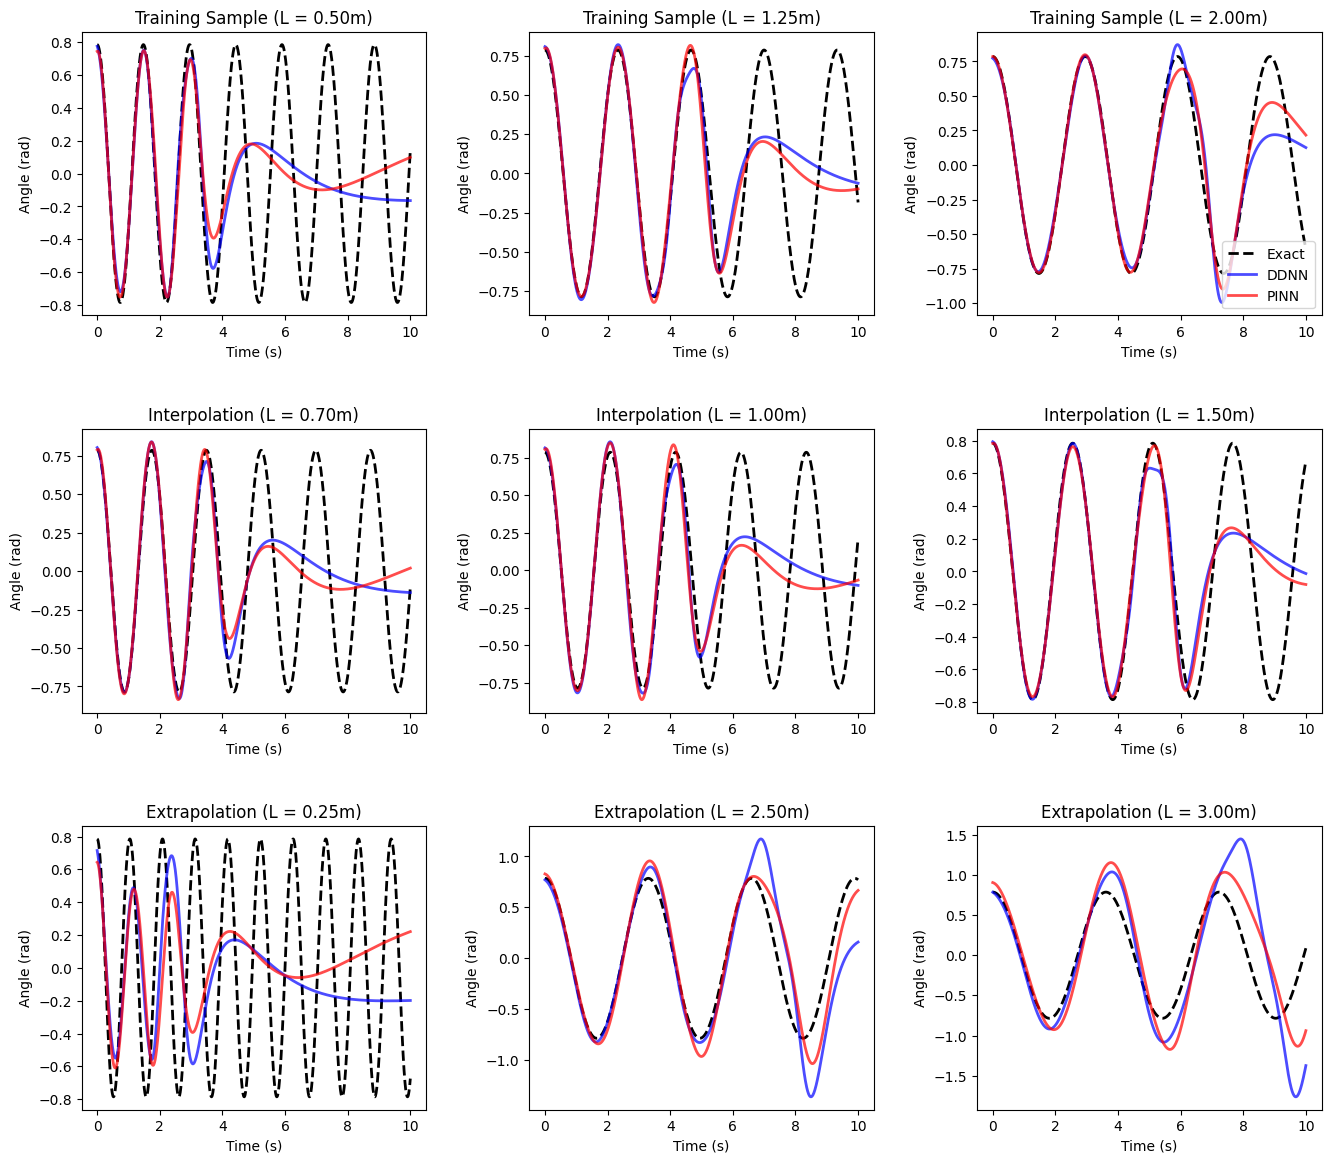

In [ ]:
# --- TRAINING LOOP 5000 Steps - Model (2, 20, 20, 20, 20, 1) ---
key = jax.random.PRNGKey(0)
layers = [2, 20, 20, 20, 20, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(5000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING (3 Rows: Training, Interpolation, Extrapolation) ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 3 training lengths)
print("--- TRAINING ERRORS (3 Samples) ---")
# Pick 3 representative lengths from your training set [0.5, 0.875, 1.25, 1.625, 2.0]
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end, resolution)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row)
print("\n--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 0.7447 | PINN L2: 0.8331
Train L=1.25 | DDNN L2: 0.3786 | PINN L2: 0.5576
Train L=2.00 | DDNN L2: 0.1307 | PINN L2: 0.2133

--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 0.6842 | PINN L2: 0.7647
L=1.00 | DDNN L2: 0.6273 | PINN L2: 0.6647
L=1.50 | DDNN L2: 0.2611 | PINN L2: 0.4353

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.1253 | PINN L2: 1.0691
L=2.50 | DDNN L2: 0.5801 | PINN L2: 0.3379
L=3.00 | DDNN L2: 1.0319 | PINN L2: 0.6065


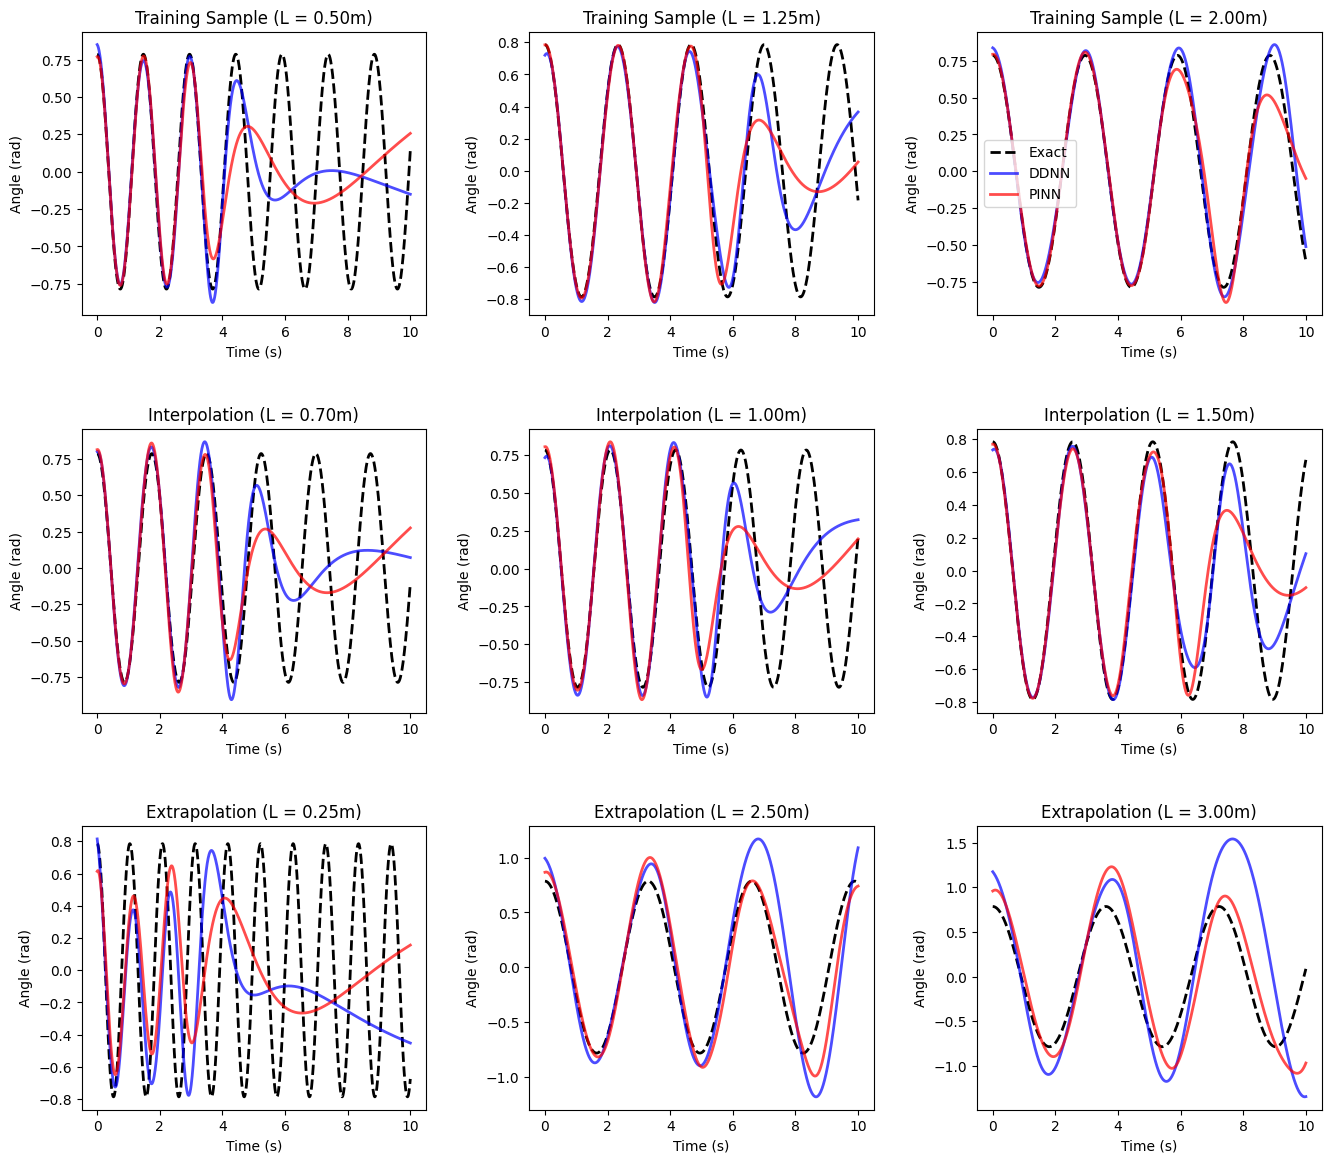

In [ ]:
# --- TRAINING LOOP 10,000 Steps - Model (2, 20, 20, 20, 20, 1) ---
key = jax.random.PRNGKey(0)
layers = [2, 20, 20, 20, 20, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(10000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING (3 Rows: Training, Interpolation, Extrapolation) ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 3 training lengths)
print("--- TRAINING ERRORS (3 Samples) ---")
# Pick 3 representative lengths from your training set [0.5, 0.875, 1.25, 1.625, 2.0]
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end, resolution)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row)
print("\n--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

### Results and Findings: Parametric Model (2, 20, 20, 20, 20, 1) - 5,000 & 10,000 Training Steps

When analyzing the results, a key pattern that stands out is that both models consistently lose predictive accuracy over longer time horizons. Furthermore, unlike the model trained from the original single-pendulum research, our parameterized model struggles to track its training data perfectly. This is likely due to the network needing to generalize across varying rod lengths ($L$), meaning it cannot rely on memorizing a single fixed frequency.

Interestingly, both models maintain high accuracy close to $t = 0$. This initial precision occurs because the data is heavily anchored to the starting angle, significantly reducing variance at the boundary. However, as the time horizon increases, both models eventually default to predicting the mean. 

While we initially hypothesized that increasing the training steps from 5,000 to 10,000 might resolve this, empirical testing showed only negligible improvement, suggesting this is a limitation of network capacity rather than a shortage of epochs. We suspect that under standard Mean Squared Error (MSE) loss, the optimizer finds it "safer" to collapse toward the mean to minimize global error once phase synchronization is lost over time. 

To address this, our next step will be to increase the physics regularization weight and expand the network's hidden layer capacity to better handle multi-cycle 2D dynamics.

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 0.6862 | PINN L2: 0.5991
Train L=1.25 | DDNN L2: 0.2510 | PINN L2: 0.1038
Train L=2.00 | DDNN L2: 0.0543 | PINN L2: 0.0258

--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 0.6141 | PINN L2: 0.5049
L=1.00 | DDNN L2: 0.5602 | PINN L2: 0.2424
L=1.50 | DDNN L2: 0.0878 | PINN L2: 0.0361

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.5096 | PINN L2: 1.0621
L=2.50 | DDNN L2: 0.2318 | PINN L2: 0.1496
L=3.00 | DDNN L2: 0.3675 | PINN L2: 0.3512


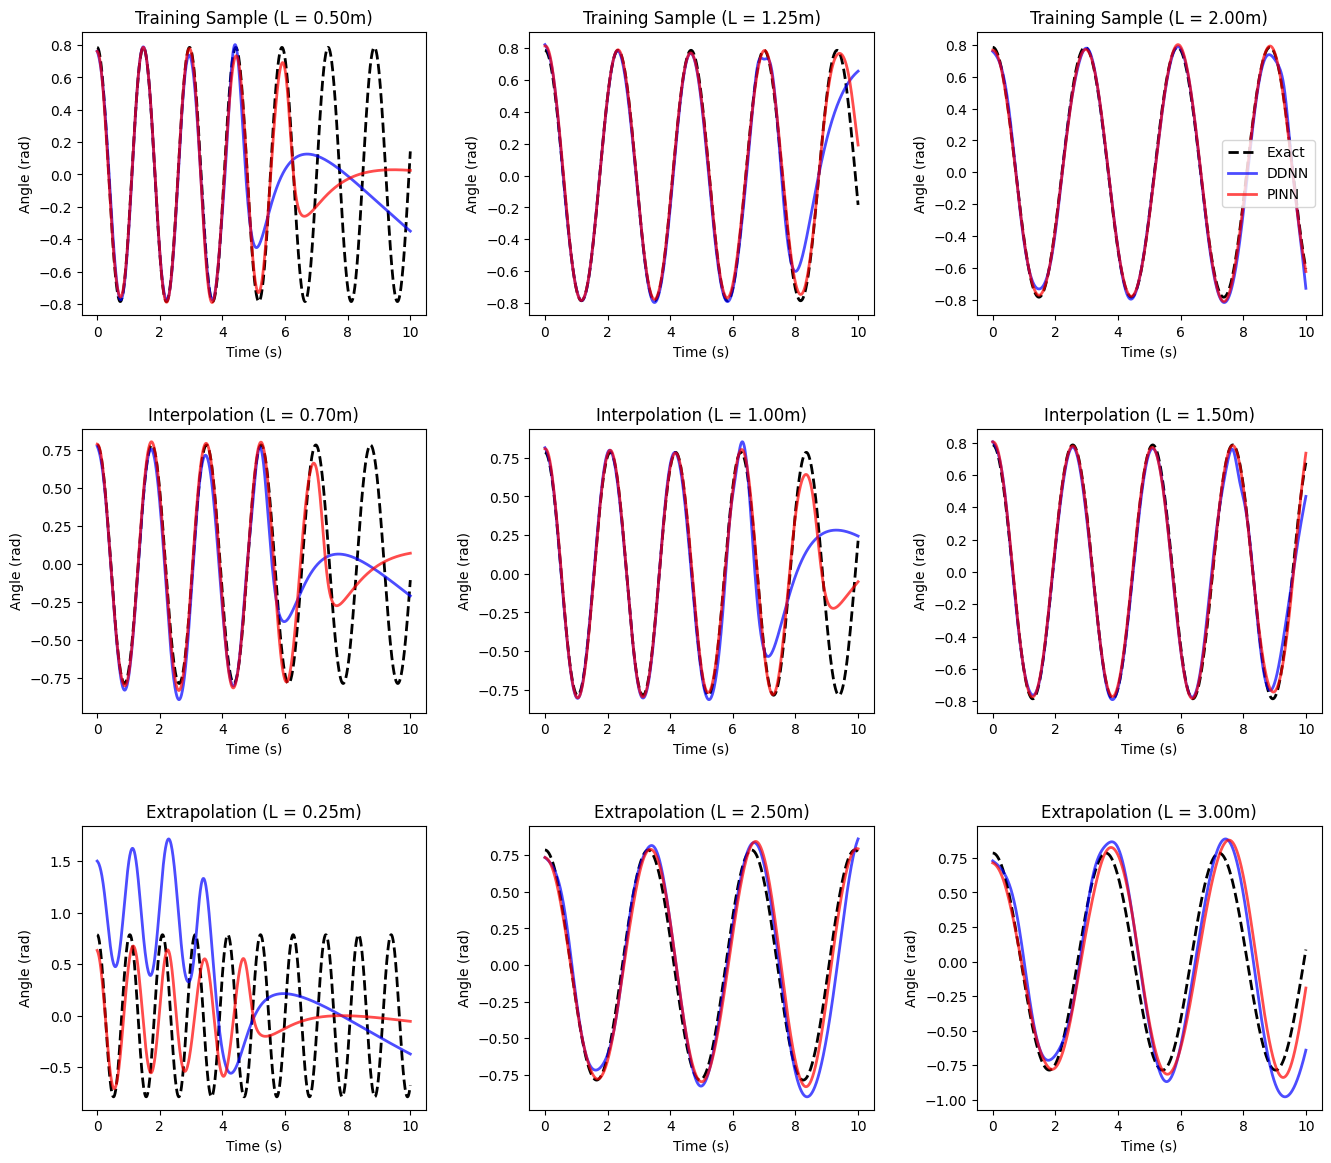

In [ ]:
# --- TRAINING LOOP 5000 Steps - Model (2, 64, 64, 64, 64, 1) ---
key = jax.random.PRNGKey(0)
layers = [2, 64, 64, 64, 64, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(5000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING (3 Rows: Training, Interpolation, Extrapolation) ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 3 training lengths)
print("--- TRAINING ERRORS (3 Samples) ---")
# Pick 3 representative lengths from your training set [0.5, 0.875, 1.25, 1.625, 2.0]
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end, resolution)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row)
print("\n--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 0.8696 | PINN L2: 0.8873
Train L=1.25 | DDNN L2: 0.6960 | PINN L2: 0.7333
Train L=2.00 | DDNN L2: 0.5461 | PINN L2: 0.6223

--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 0.8249 | PINN L2: 0.8441
L=1.00 | DDNN L2: 0.7733 | PINN L2: 0.7918
L=1.50 | DDNN L2: 0.6787 | PINN L2: 0.7011

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.0101 | PINN L2: 0.9997
L=2.50 | DDNN L2: 0.5061 | PINN L2: 0.5924
L=3.00 | DDNN L2: 0.5895 | PINN L2: 0.6253


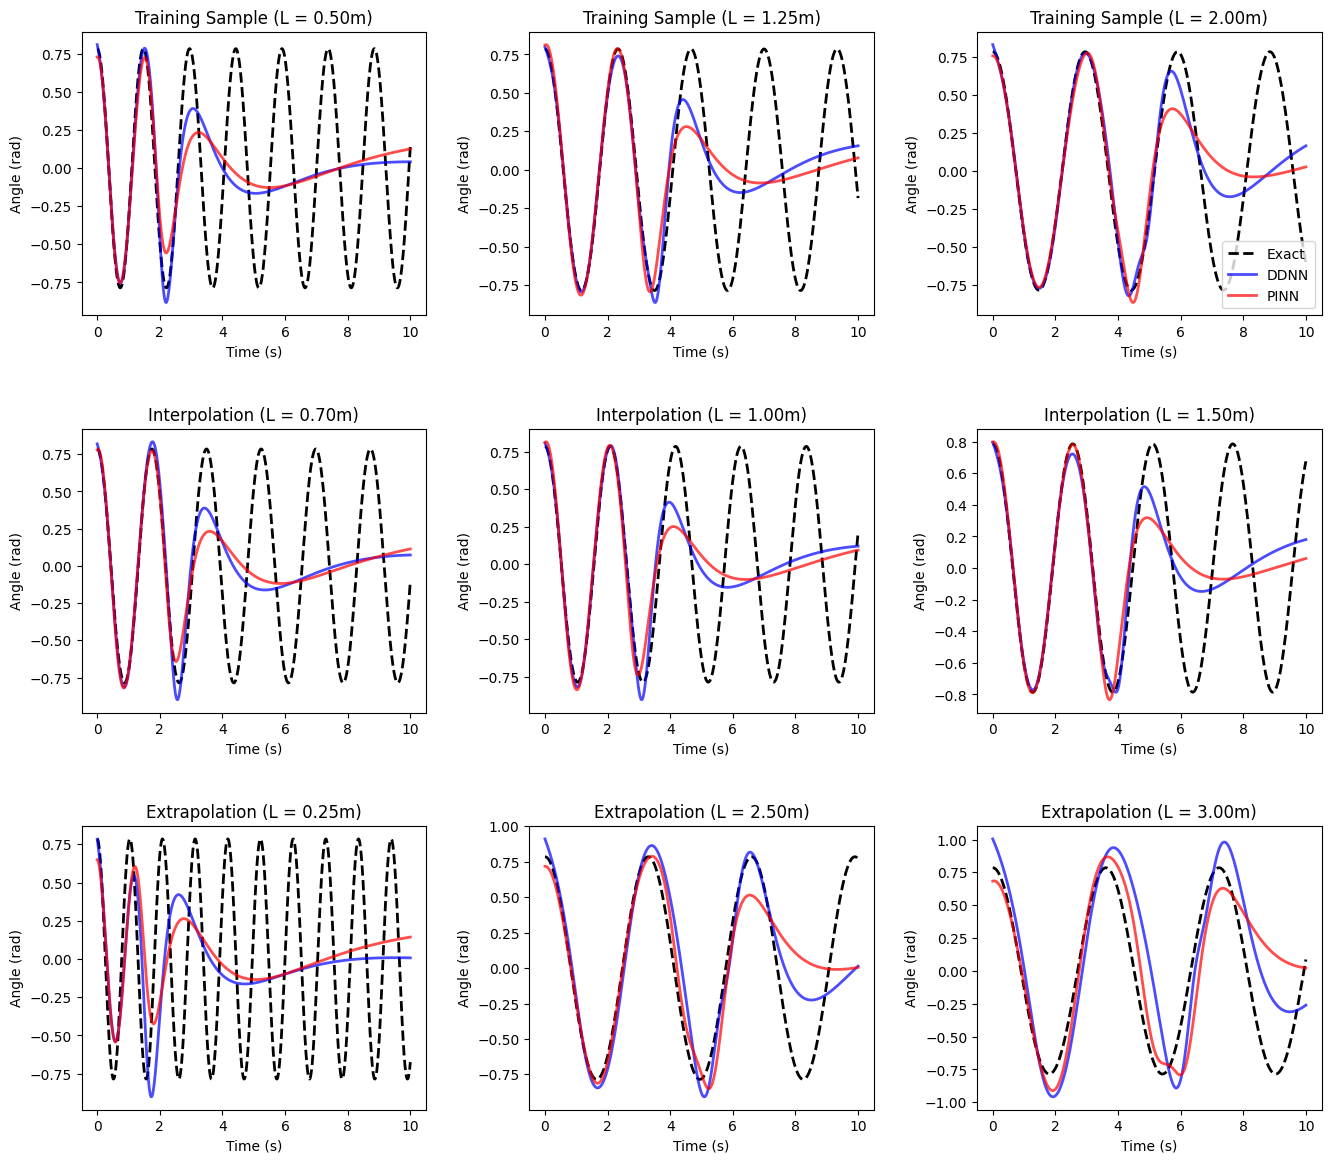

In [ ]:
# --- TRAINING LOOP 5000 Steps - Model (2, 20, 20, 20, 20, 20, 20, 1) ---
key = jax.random.PRNGKey(0)
layers = [2, 20, 20, 20, 20, 20, 20, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(5000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING (3 Rows: Training, Interpolation, Extrapolation) ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 3 training lengths)
print("--- TRAINING ERRORS (3 Samples) ---")
# Pick 3 representative lengths from your training set [0.5, 0.875, 1.25, 1.625, 2.0]
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end, resolution)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row)
print("\n--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 0.5174 | PINN L2: 0.4869
Train L=1.25 | DDNN L2: 0.0491 | PINN L2: 0.0490
Train L=2.00 | DDNN L2: 0.0283 | PINN L2: 0.0509

--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 0.6905 | PINN L2: 0.2752
L=1.00 | DDNN L2: 0.3044 | PINN L2: 0.0933
L=1.50 | DDNN L2: 0.0395 | PINN L2: 0.0522

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.4739 | PINN L2: 1.0921
L=2.50 | DDNN L2: 0.1326 | PINN L2: 0.1210
L=3.00 | DDNN L2: 0.2278 | PINN L2: 0.2700


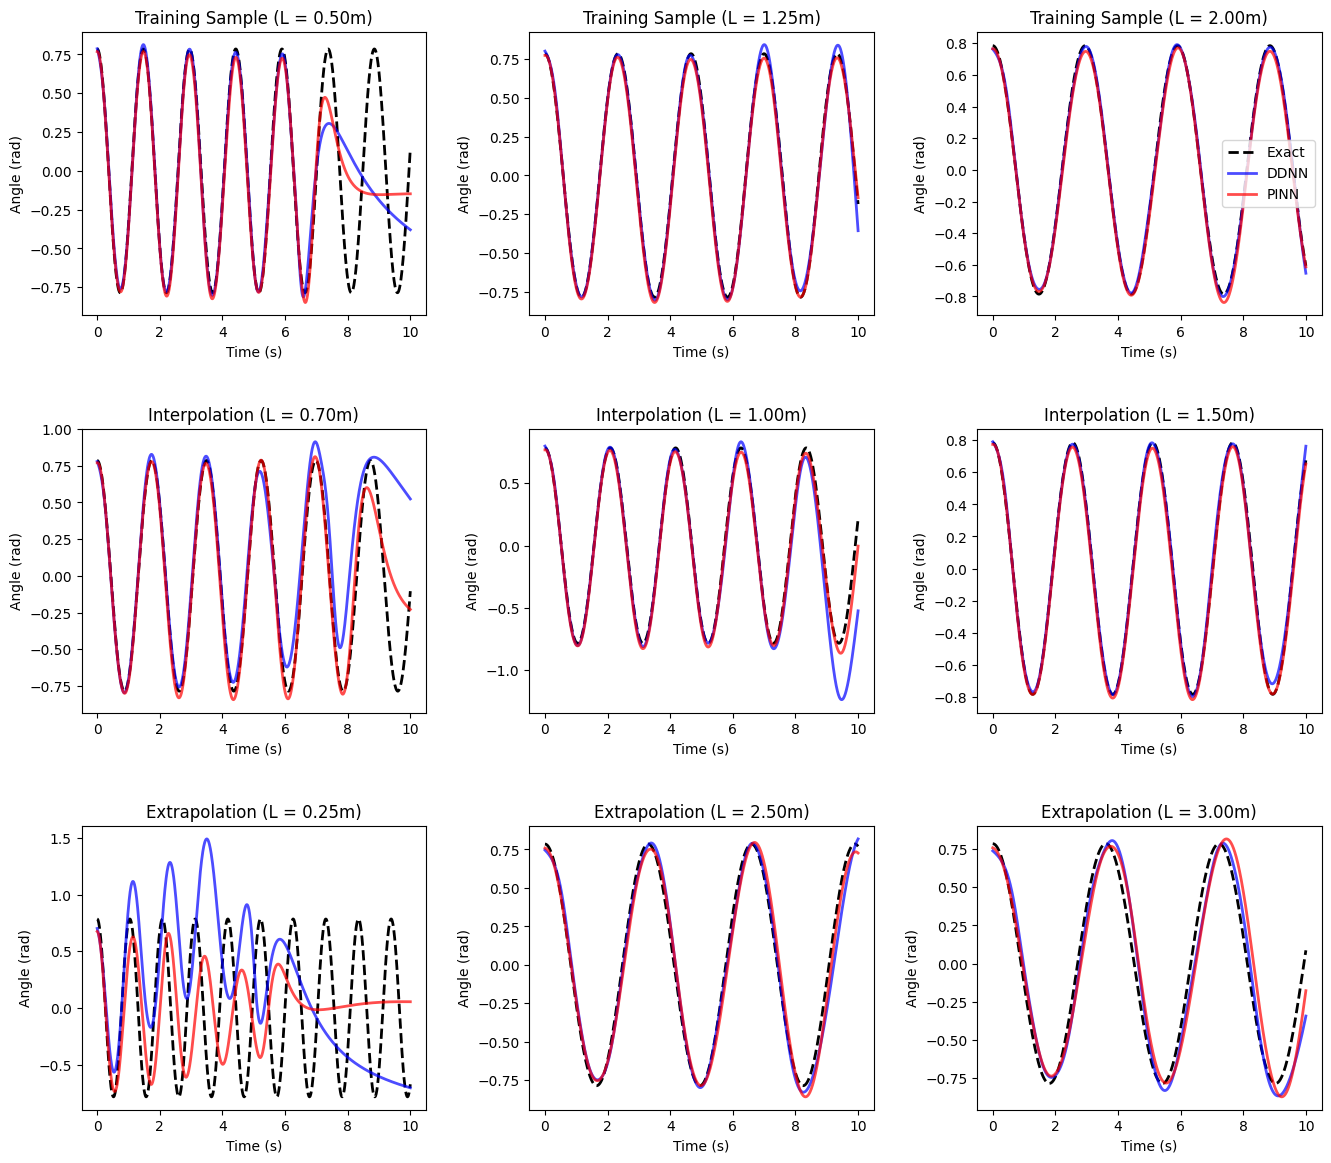

In [8]:
# --- TRAINING LOOP 10,000 Steps - Model (2, 64, 64, 64, 64, 1) ---
key = jax.random.PRNGKey(0)
layers = [2, 64, 64, 64, 64, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(10000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING (3 Rows: Training, Interpolation, Extrapolation) ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 3 training lengths)
print("--- TRAINING ERRORS (3 Samples) ---")
# Pick 3 representative lengths from your training set [0.5, 0.875, 1.25, 1.625, 2.0]
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end, resolution)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row)
print("\n--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 0.1925 | PINN L2: 0.1337
Train L=1.25 | DDNN L2: 0.0271 | PINN L2: 0.0360
Train L=2.00 | DDNN L2: 0.0313 | PINN L2: 0.0296

--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 0.2645 | PINN L2: 0.0878
L=1.00 | DDNN L2: 0.0795 | PINN L2: 0.0445
L=1.50 | DDNN L2: 0.0414 | PINN L2: 0.0414

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.3238 | PINN L2: 1.1663
L=2.50 | DDNN L2: 0.1105 | PINN L2: 0.1074
L=3.00 | DDNN L2: 0.2704 | PINN L2: 0.2582


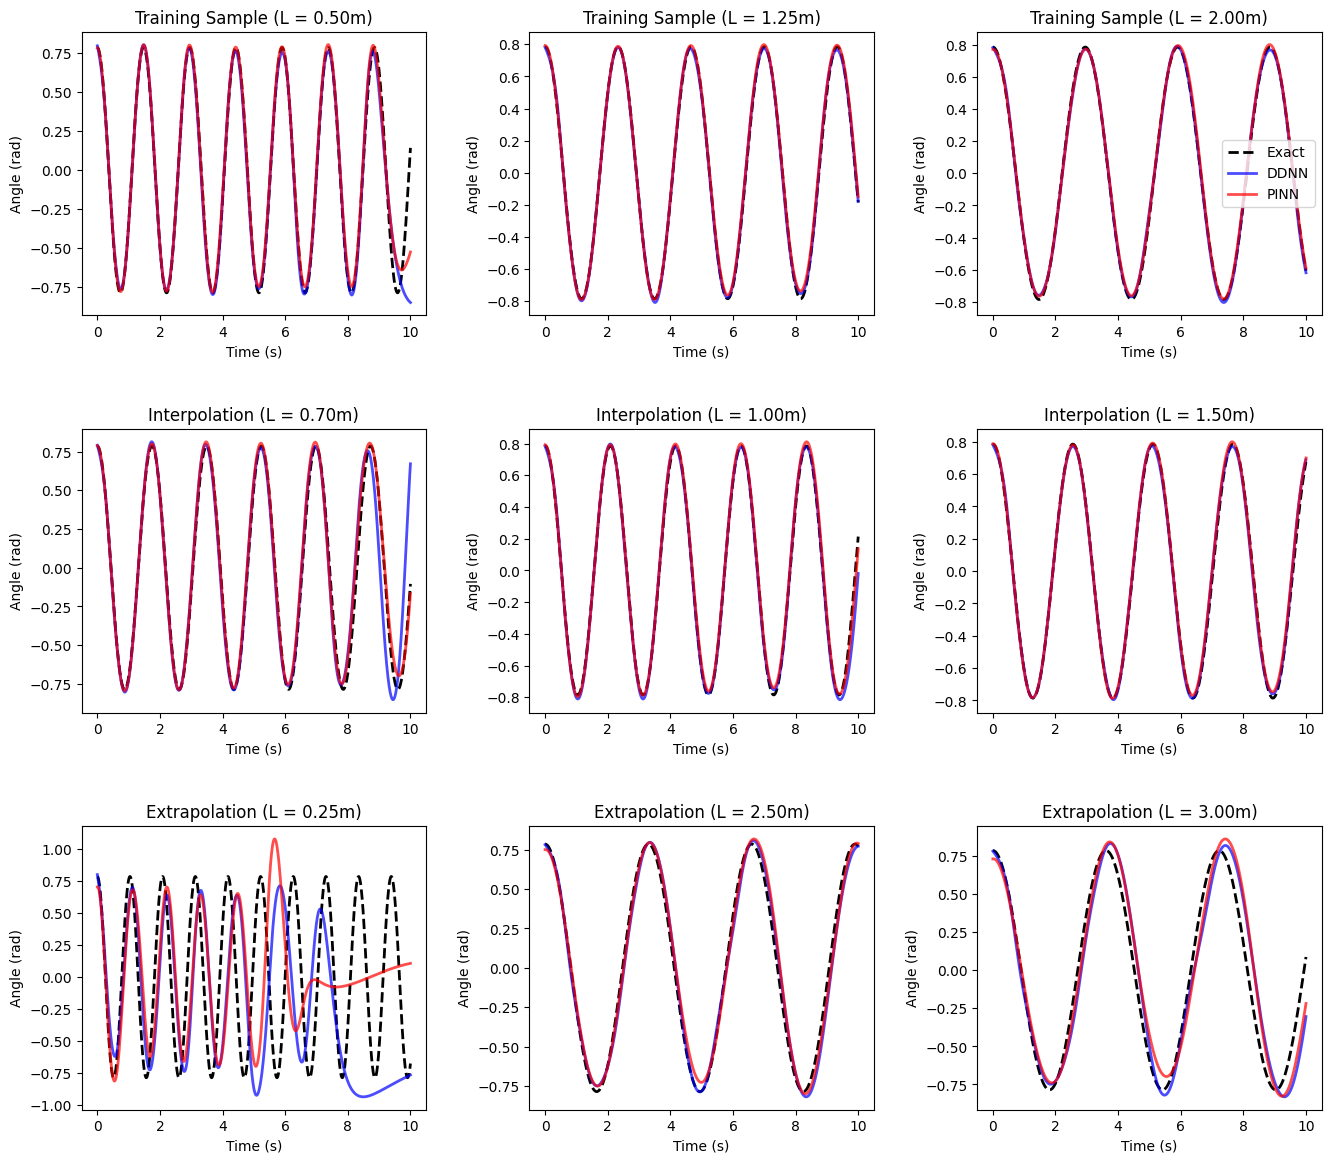

In [ ]:
# --- TRAINING LOOP 10,000 Steps - Model (2, 128, 128, 128, 128, 1) ---
key = jax.random.PRNGKey(0)
layers = [2, 128, 128, 128, 128, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(10000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING (3 Rows: Training, Interpolation, Extrapolation) ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 3 training lengths)
print("--- TRAINING ERRORS (3 Samples) ---")
# Pick 3 representative lengths from your training set [0.5, 0.875, 1.25, 1.625, 2.0]
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end, resolution)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row)
print("\n--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

### Results and Findings: Width & Depth Scaling Study (64/128 Width vs. Deep Architecture) - 5,000 & 10,000 Training Steps

To address our accuracy bottlenecks, we conducted an architectural grid test style study testing two key modifications: increasing model width (neurons per layer) and increasing model depth (number of layers). 

Increasing model depth led to a sharp performance regression. This is likely because the model became too deep, rendering the optimization landscape overly complex and difficult to traverse due to gradient pathology in the higher-order derivative calculations. 

Conversely, increasing model width yielded significant improvements. The wider models successfully and smoothly tracked lower-frequency patterns (high $L$), though they still fell short on faster, higher-frequency oscillations (low $L$). A critical observation is that even for lower-frequency patterns, the predictions eventually begin to phase-drift and collapse toward the mean over an extended time horizon. Meaning we could likely expect similair behavior for lower-frequency patterns over longer time horizons.

Based on these results, we have identified three major directions to test next:
1. **Residual Connections (ResNets):** Investigate whether modifying the architecture into a residual network can alleviate gradient degradation and make increased depth a viable improvement.
2. **Scaling Plateaus:** Map the point of diminishing returns. Scaling from 64 to 128 neurons per layer showed minimal overall improvement, indicating we are reaching an architectural plateau where width alone cannot overcome long-term phase error.
3. **Physics Regularization Tuning:** Test whether increasing the weight of the physics loss term forces the model to respect frequency patterns more strictly, rather than hedging its bets by predicting averages.

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 0.6862 | PINN L2: 0.6978
Train L=1.25 | DDNN L2: 0.2510 | PINN L2: 0.2555
Train L=2.00 | DDNN L2: 0.0543 | PINN L2: 0.0664

--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 0.6141 | PINN L2: 0.6234
L=1.00 | DDNN L2: 0.5602 | PINN L2: 0.5372
L=1.50 | DDNN L2: 0.0878 | PINN L2: 0.1133

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.5096 | PINN L2: 0.9428
L=2.50 | DDNN L2: 0.2318 | PINN L2: 0.0979
L=3.00 | DDNN L2: 0.3675 | PINN L2: 0.2612


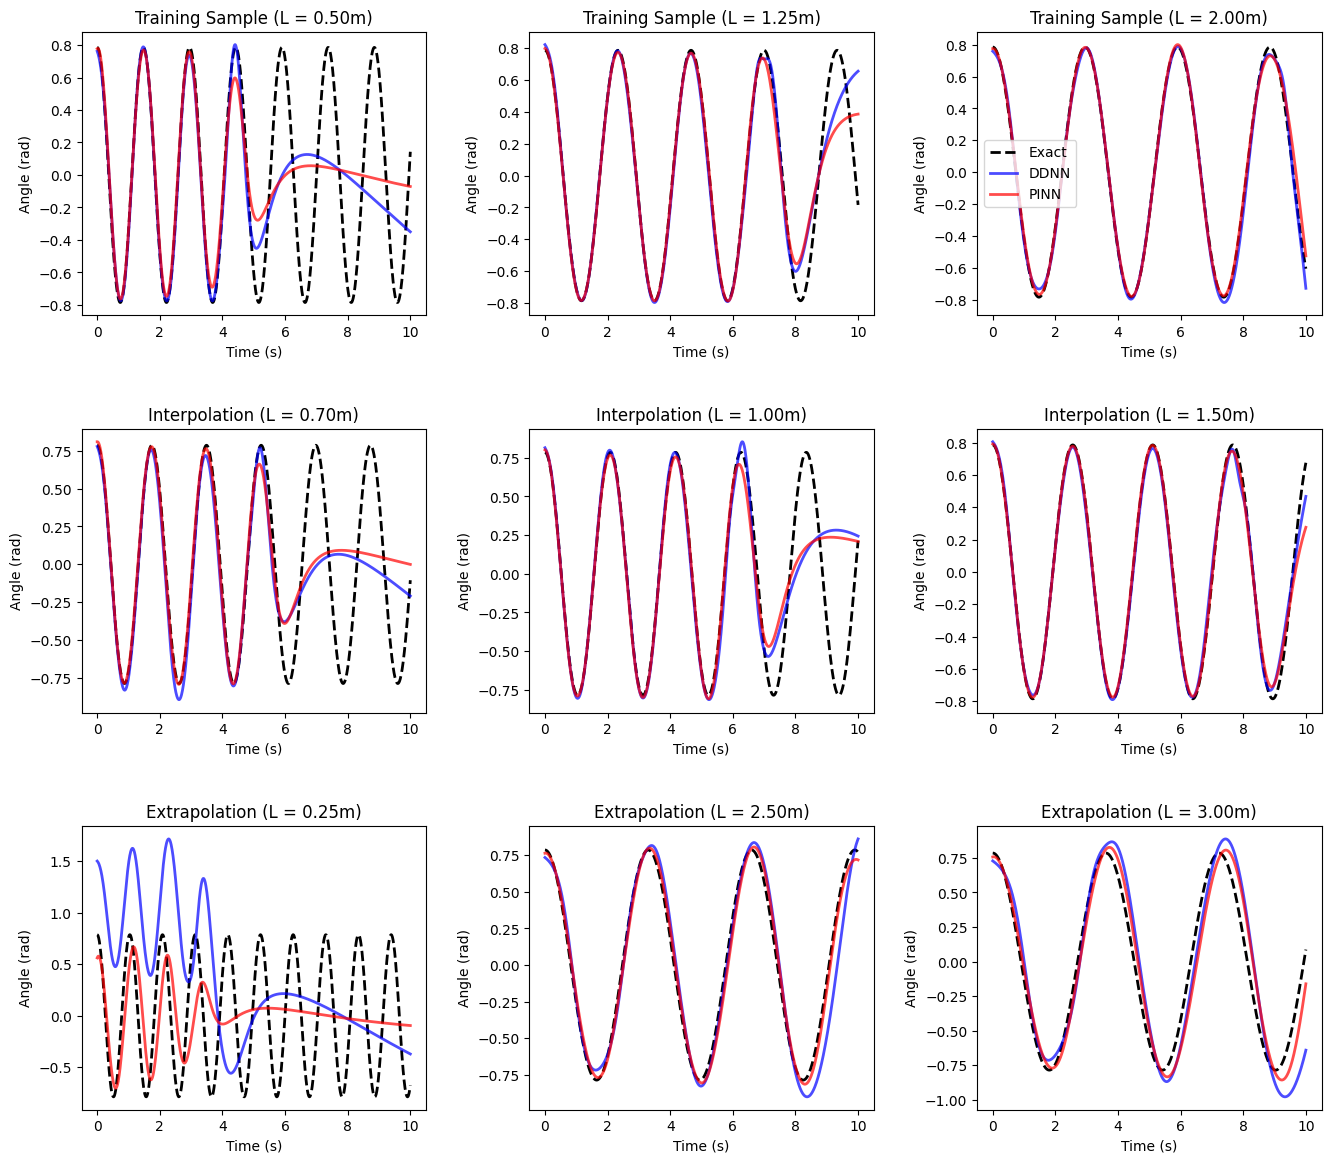

In [5]:
# --- TRAINING LOOP 5000 Steps - Model (2, 64, 64, 64, 64, 1) ---
# updating physics loss 0.001 -> 0.01 to test effect
@jax.jit
def loss_PINN(params, X, theta_true, t_c, L_c):
    data_loss = loss_DDNN(params, X, theta_true)
    physics_loss = jnp.mean(r_PINN_vmap(params, t_c, L_c)**2)
    return data_loss + 0.01 * physics_loss

key = jax.random.PRNGKey(0)
layers = [2, 64, 64, 64, 64, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(5000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING (3 Rows: Training, Interpolation, Extrapolation) ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 3 training lengths)
print("--- TRAINING ERRORS (3 Samples) ---")
# Pick 3 representative lengths from your training set [0.5, 0.875, 1.25, 1.625, 2.0]
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end, resolution)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row)
print("\n--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 0.5174 | PINN L2: 0.5391
Train L=1.25 | DDNN L2: 0.0491 | PINN L2: 0.0369
Train L=2.00 | DDNN L2: 0.0283 | PINN L2: 0.0348

--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 0.6905 | PINN L2: 0.3872
L=1.00 | DDNN L2: 0.3044 | PINN L2: 0.0793
L=1.50 | DDNN L2: 0.0395 | PINN L2: 0.0498

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.4739 | PINN L2: 0.9823
L=2.50 | DDNN L2: 0.1326 | PINN L2: 0.1172
L=3.00 | DDNN L2: 0.2278 | PINN L2: 0.2612


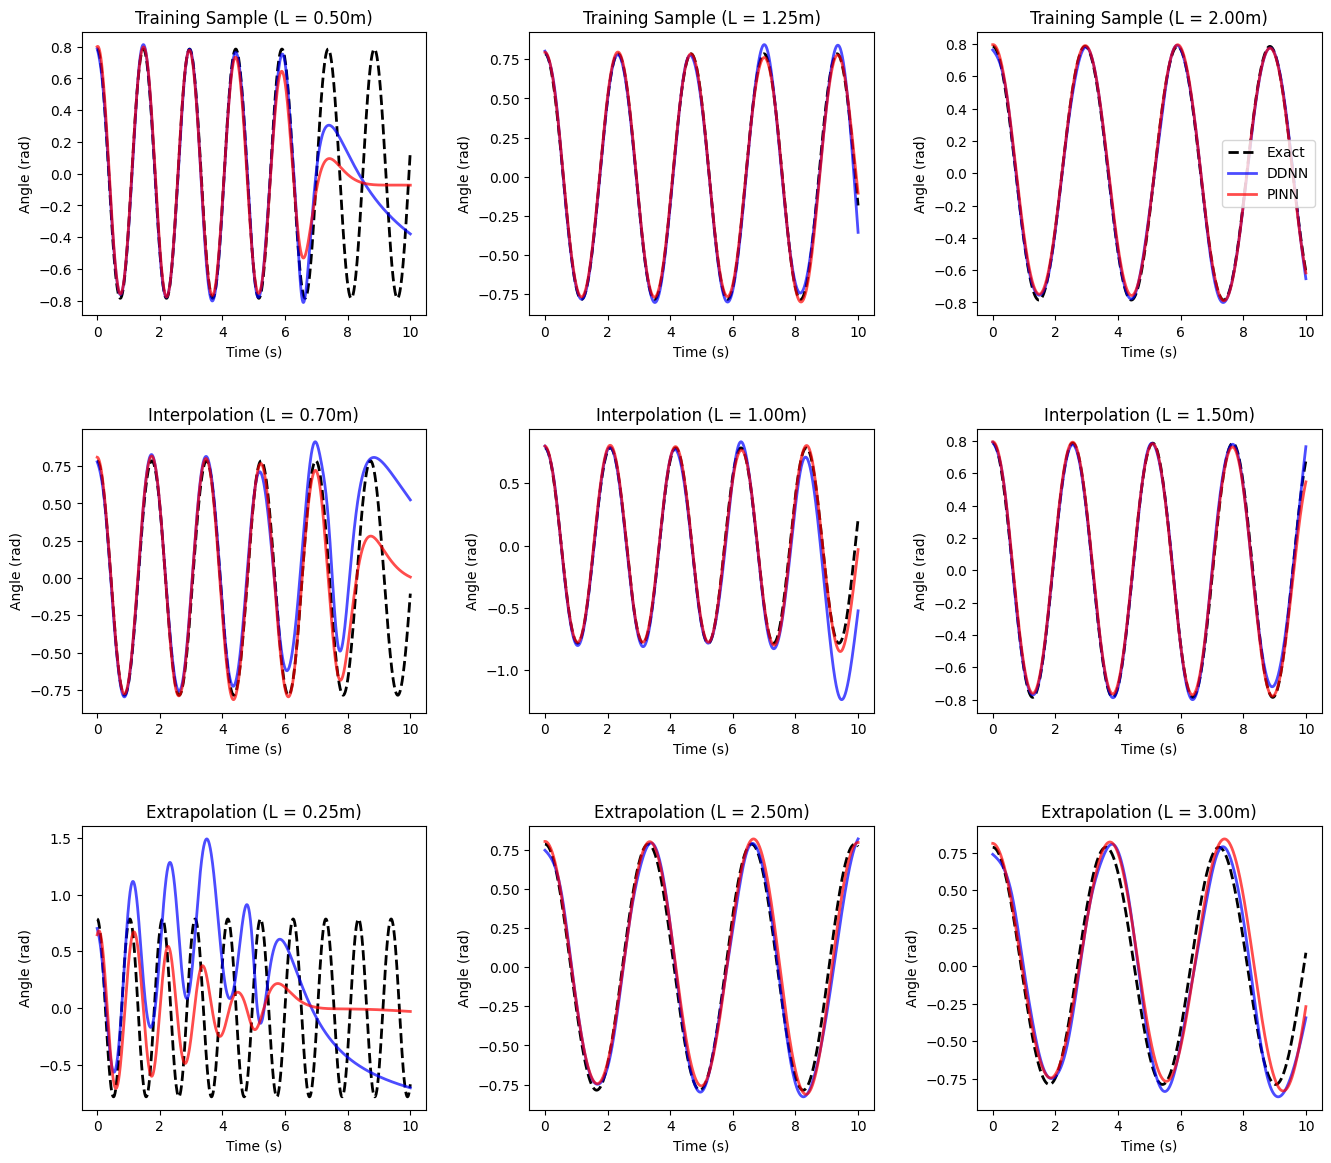

In [6]:
# --- TRAINING LOOP 10,000 Steps - Model (2, 64, 64, 64, 64, 1) ---
# updating physics loss 0.001 -> 0.01 to test effect
@jax.jit
def loss_PINN(params, X, theta_true, t_c, L_c):
    data_loss = loss_DDNN(params, X, theta_true)
    physics_loss = jnp.mean(r_PINN_vmap(params, t_c, L_c)**2)
    return data_loss + 0.01 * physics_loss

key = jax.random.PRNGKey(0)
layers = [2, 64, 64, 64, 64, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(10000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING (3 Rows: Training, Interpolation, Extrapolation) ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 3 training lengths)
print("--- TRAINING ERRORS (3 Samples) ---")
# Pick 3 representative lengths from your training set [0.5, 0.875, 1.25, 1.625, 2.0]
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end, resolution)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row)
print("\n--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

### Results and Findings: Physics Loss Weight Adjustment (0.001 vs. 0.01) - 5,000 & 10,000 Training Steps

We initially hypothesized that the model's tendency to collapse toward the mean over long time horizons occurred because the physics residual wasn't being weighted heavily enough during training. To test this, we increased the physics regularization weight from 0.001 to 0.01, aiming to force the optimizer to prioritize the underlying differential equations over simply minimizing the Mean Squared Error (MSE) of the data points.

However, empirical testing revealed that this adjustment yielded no visible improvement. In fact, the higher physics weight led to slightly degraded predictive performance compared to the model trained with the original weighting. 

This outcome suggests that the phase drift is not caused by a weak physics penalty, but rather by optimization "stiffness." Merely increasing the penalty does not help the network learn the high-frequency dynamics; instead, it likely causes the data loss and physics loss gradients to compete more aggressively, ultimately halting the optimizer's progress.

In [7]:
# --- ARCHITECTURE & PHYSICS RESIDUAL ---
def init_params(key, layers):
    keys = jax.random.split(key, len(layers) - 1)
    params = []
    for k, n_in, n_out in zip(keys, layers[:-1], layers[1:]):
        W = jax.random.uniform(k, shape=(n_in, n_out), minval=-np.sqrt(1/n_in), maxval=np.sqrt(1/n_in))
        B = jnp.zeros((n_out,))
        params.append({'W': W, 'B': B})
    return params

def apply_fourier_features(X):
    # X[..., 0:1] extracts time 't' while keeping the array shape consistent
    t = X[..., 0:1] 
    
    # Create 4 base frequencies
    freqs = jnp.array([1.0, 2.0, 4.0, 8.0])
    
    # Calculate sine and cosine waves for time at these frequencies
    sin_features = jnp.sin(t * freqs)
    cos_features = jnp.cos(t * freqs)
    
    # Combine original [t, L] with the 8 new Fourier features
    return jnp.concatenate([X, sin_features, cos_features], axis=-1)

def NN(X, params):
    # Pass input through the Fourier transformation first
    H = apply_fourier_features(X)
    
    hidden, last = params[:-1], params[-1]
    for layer in hidden:
        H = jax.nn.tanh(jnp.dot(H, layer['W']) + layer['B'])
    return jnp.dot(H, last['W']) + last['B']

# Scalar version of the network for clean differentiation
def get_theta_scalar(params, t, L):
    X = jnp.array([t, L])
    return NN(X, params)[0]

# Differentiate ONLY with respect to time (argnums=1)
grad_t = jax.grad(get_theta_scalar, argnums=1)
grad_tt = jax.grad(grad_t, argnums=1)

def r_PINN_scalar(params, t, L):
    theta = get_theta_scalar(params, t, L)
    theta_tt = grad_tt(params, t, L)
    return theta_tt + (9.81 / L) * jnp.sin(theta)

# Vectorize the scalar residual function for batch processing
r_PINN_vmap = jax.vmap(r_PINN_scalar, in_axes=(None, 0, 0))

# --- CELL 4: LOSS FUNCTIONS ---
@jax.jit
def loss_DDNN(params, X, theta_true):
    theta_pred = NN(X, params)
    return jnp.mean((theta_true - theta_pred)**2)

@jax.jit
def loss_PINN(params, X, theta_true, t_c, L_c):
    data_loss = loss_DDNN(params, X, theta_true)
    physics_loss = jnp.mean(r_PINN_vmap(params, t_c, L_c)**2)
    return data_loss + 0.001 * physics_loss

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 0.2131 | PINN L2: 0.0356
Train L=1.25 | DDNN L2: 0.1483 | PINN L2: 0.0453
Train L=2.00 | DDNN L2: 0.2244 | PINN L2: 0.0230

--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 1.3935 | PINN L2: 1.2928
L=1.00 | DDNN L2: 1.0990 | PINN L2: 0.8300
L=1.50 | DDNN L2: 0.5339 | PINN L2: 0.2189

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.9518 | PINN L2: 2.6087
L=2.50 | DDNN L2: 1.0914 | PINN L2: 0.4081
L=3.00 | DDNN L2: 1.7770 | PINN L2: 0.7825


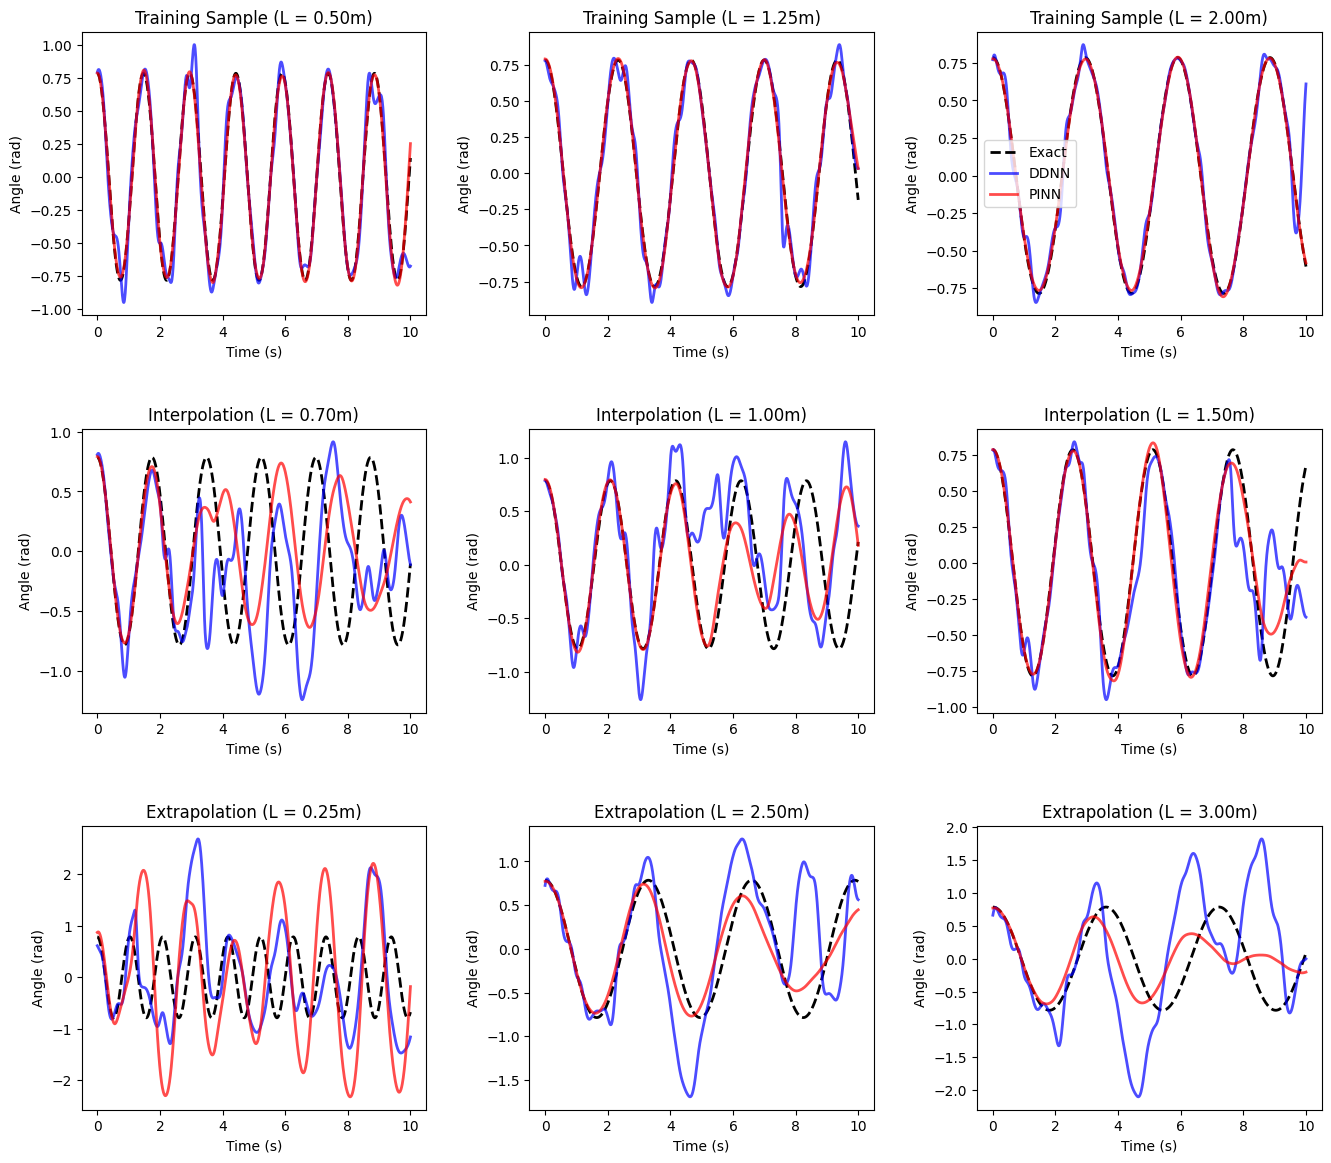

In [8]:
# --- TRAINING LOOP 10,000 Steps - Model (2, 64, 64, 64, 64, 1) ---
key = jax.random.PRNGKey(0)
layers = [10, 64, 64, 64, 64, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(10000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING (3 Rows: Training, Interpolation, Extrapolation) ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 3 training lengths)
print("--- TRAINING ERRORS (3 Samples) ---")
# Pick 3 representative lengths from your training set [0.5, 0.875, 1.25, 1.625, 2.0]
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end, resolution)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row)
print("\n--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

In [9]:
# --- ARCHITECTURE & PHYSICS RESIDUAL (TIME-WARPING PINN) ---
def init_params(key, layers_omega, layers_wave):
    key_w, key_t = jax.random.split(key)
    
    def init_mlp(k, layers):
        keys = jax.random.split(k, len(layers) - 1)
        params = []
        for k_i, n_in, n_out in zip(keys, layers[:-1], layers[1:]):
            W = jax.random.uniform(k_i, shape=(n_in, n_out), minval=-np.sqrt(1/n_in), maxval=np.sqrt(1/n_in))
            B = jnp.zeros((n_out,))
            params.append({'W': W, 'B': B})
        return params
        
    # Return a dictionary containing both sub-networks
    return {
        'omega': init_mlp(key_w, layers_omega),
        'wave': init_mlp(key_t, layers_wave)
    }

def evaluate_mlp(X, params):
    hidden, last = params[:-1], params[-1]
    for layer in hidden:
        X = jax.nn.tanh(jnp.dot(X, layer['W']) + layer['B'])
    return jnp.dot(X, last['W']) + last['B']

def NN(X, params):
    t = X[..., 0:1] # Extract time
    L = X[..., 1:2] # Extract length
    
    # 1. Branch A: Predict frequency scaling (omega) from Length
    w = evaluate_mlp(L, params['omega'])
    
    # 2. Merge: Warp Time
    tau = w * t
    
    # 3. Branch B: Predict final angle from warped time
    theta = evaluate_mlp(tau, params['wave'])
    return theta

# Scalar version for clean differentiation
def get_theta_scalar(params, t, L):
    X = jnp.array([t, L])
    return NN(X, params)[0]

# Differentiate ONLY with respect to time (argnums=1)
grad_t = jax.grad(get_theta_scalar, argnums=1)
grad_tt = jax.grad(grad_t, argnums=1)

def r_PINN_scalar(params, t, L):
    theta = get_theta_scalar(params, t, L)
    theta_tt = grad_tt(params, t, L)
    return theta_tt + (9.81 / L) * jnp.sin(theta)

r_PINN_vmap = jax.vmap(r_PINN_scalar, in_axes=(None, 0, 0))

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 0.9979 | PINN L2: 0.7848
Train L=1.25 | DDNN L2: 1.0014 | PINN L2: 0.5916
Train L=2.00 | DDNN L2: 0.9995 | PINN L2: 0.4064

--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 1.0016 | PINN L2: 0.7383
L=1.00 | DDNN L2: 1.0048 | PINN L2: 0.6675
L=1.50 | DDNN L2: 0.9985 | PINN L2: 0.5502

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.0394 | PINN L2: 0.9200
L=2.50 | DDNN L2: 1.0709 | PINN L2: 0.4998
L=3.00 | DDNN L2: 1.4286 | PINN L2: 1.0008


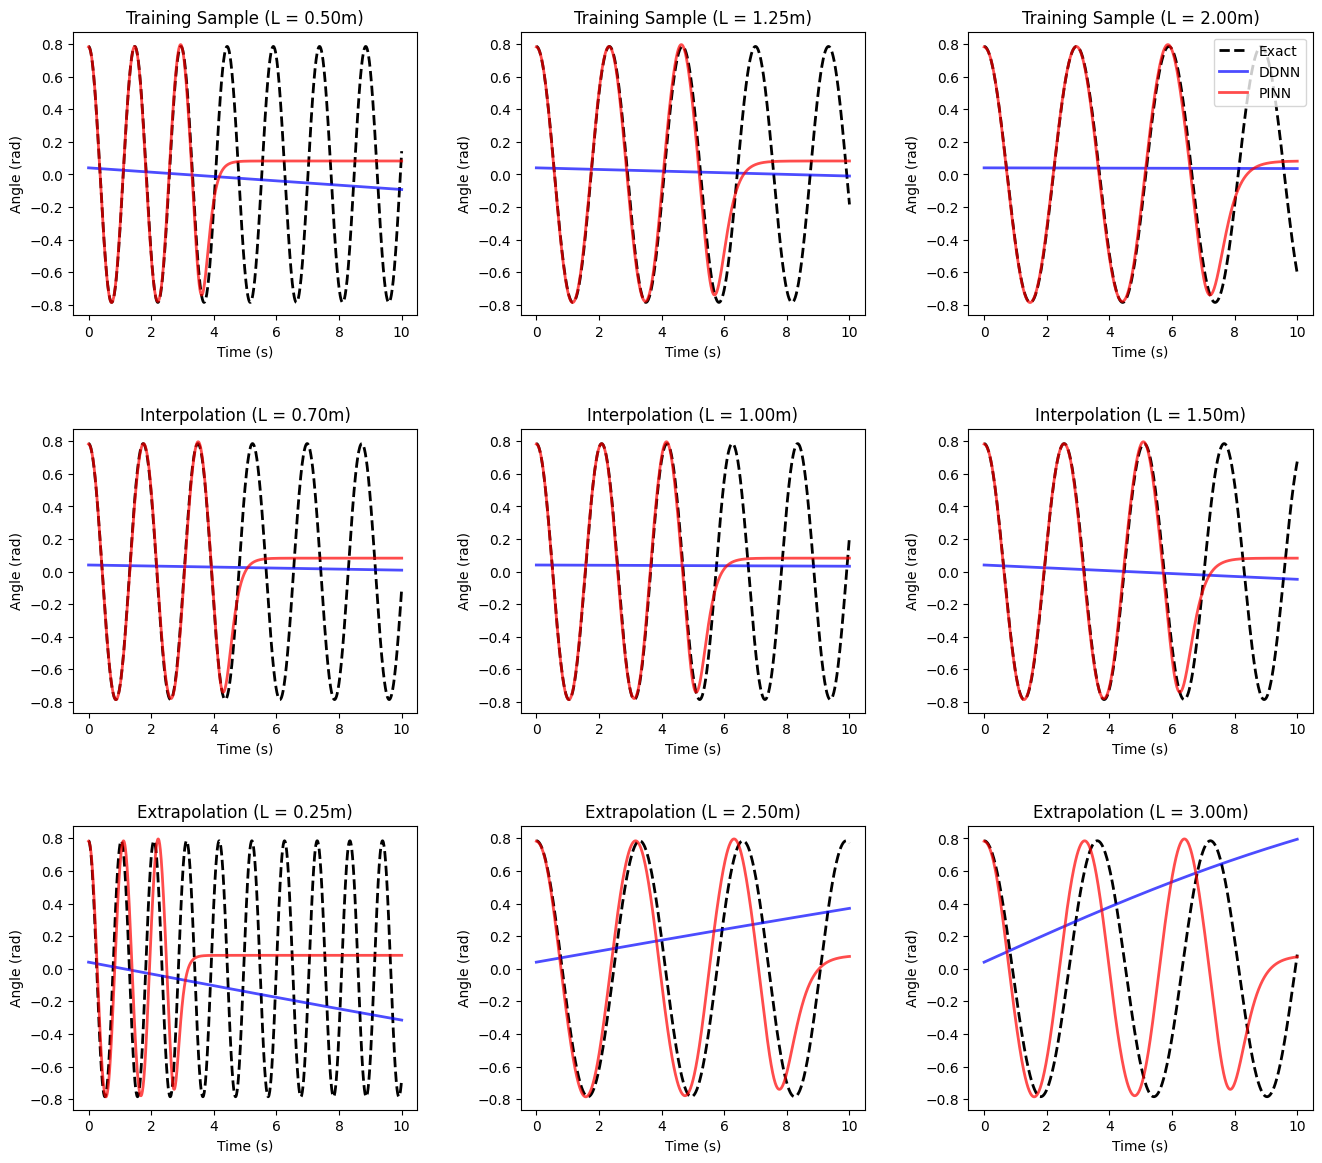

In [10]:
# --- TRAINING LOOP 10,000 Steps - Model Y Omega (1, 10, 10, 1) Wave (1, 20, 20, 20, 1) ---
key = jax.random.PRNGKey(0)

# Branch A: Takes 1 input (L), uses 2 small hidden layers, outputs 1 (omega)
layers_omega = [1, 10, 10, 1] 

# Branch B: Takes 1 input (tau), uses 3 hidden layers, outputs 1 (theta)
layers_wave = [1, 20, 20, 20, 1] 

params_DDNN = init_params(key, layers_omega, layers_wave)
params_PINN = init_params(key, layers_omega, layers_wave)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(10000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING (3 Rows: Training, Interpolation, Extrapolation) ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 3 training lengths)
print("--- TRAINING ERRORS (3 Samples) ---")
# Pick 3 representative lengths from your training set [0.5, 0.875, 1.25, 1.625, 2.0]
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end, resolution)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row)
print("\n--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

### Results and Findings: Fourier Features and Time-Warping Architecture - 10,000 Training Steps

To overcome the long-horizon prediction barrier, we tested two novel architectural strategies rather than relying on brute-force network scaling.

**Strategy 1: Fourier Feature Mapping (Trigonometric Inputs)**
First, we attempted to augment our inputs by passing the time variable through a series of trigonometric functions. The goal was to provide the model with explicit periodic features to help it bypass spectral bias and intuitively capture frequency patterns. However, this approach failed severely. Both the DDNN and PINN models produced highly erratic predictions, suffering from high-frequency artifacting and losing all semblance of a smooth, continuous wave over time.

**Strategy 2: End-to-End Time-Warping Architecture**
Our second approach was a more complex, novel branching architecture. Rather than using a single feedforward neural network, we divided the model into two interconnected sub-networks. The first network took only the rod length ($L$) as input to predict the frequency scaling factor ($\omega$). This predicted $\omega$ was then used to scale the time input ($t$) before feeding it into the second network, which ultimately predicted the angle ($\theta$). By passing the gradients seamlessly back through the second model into the first, the entire structure trained as one unified, end-to-end model.

**Key Discoveries and The Activation Saturation Breakthrough**
This decoupled architecture yielded profound insights. Unlike all previous iterations, this model demonstrated a robust, intrinsic understanding of frequency scaling. It was the first PINN to successfully and accurately extrapolate high-frequency dynamics (low $L$), while also tracking lower frequencies well (with only minor phase shifts at higher lengths like $L = 3$). 

However, the most crucial discovery occurred when analyzing the long-term horizons: the model's predictions would abruptly flatten out. Upon investigating the network's internals, we found that as the input $t$ grew larger, the intermediary `tanh` neurons were pushed to their asymptotic limits (saturation). Once these neurons plateaued, the "flatness" cascaded through the network, ultimately infecting the final output neuron and causing the entire prediction to flatline. 

This was a breakthrough diagnostic finding. It strongly suggests that a primary reason our earlier models failed to predict over long time horizons was not just optimization stiffness or lack of capacity, but fundamental **activation function saturation** driven by a continuously growing time input.

In [6]:
# --- ARCHITECTURE & PHYSICS RESIDUAL ---
def init_params(key, layers):
    keys = jax.random.split(key, len(layers) - 1)
    params = []
    for k, n_in, n_out in zip(keys, layers[:-1], layers[1:]):
        W = jax.random.uniform(k, shape=(n_in, n_out), minval=-np.sqrt(1/n_in), maxval=np.sqrt(1/n_in))
        B = jnp.zeros((n_out,))
        params.append({'W': W, 'B': B})
    return params

def NN(X, params):
    hidden, last = params[:-1], params[-1]
    for layer in hidden:
        # 1. Replaced tanh with Swish to avoid saturation but keep 2nd derivatives
        X = jax.nn.swish(jnp.dot(X, layer['W']) + layer['B'])
        
    # 2. Calculate the raw output of the final layer
    raw_out = jnp.dot(X, last['W']) + last['B']
    
    # 3. Apply your idea: A one-neuron cosine final function
    return jnp.cos(raw_out)

# Scalar version of the network for clean differentiation
def get_theta_scalar(params, t, L):
    X = jnp.array([t, L])
    return NN(X, params)[0]

# Differentiate ONLY with respect to time (argnums=1)
grad_t = jax.grad(get_theta_scalar, argnums=1)
grad_tt = jax.grad(grad_t, argnums=1)

def r_PINN_scalar(params, t, L):
    theta = get_theta_scalar(params, t, L)
    theta_tt = grad_tt(params, t, L)
    return theta_tt + (9.81 / L) * jnp.sin(theta)

# Vectorize the scalar residual function for batch processing
r_PINN_vmap = jax.vmap(r_PINN_scalar, in_axes=(None, 0, 0))

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 0.0790 | PINN L2: 0.0540
Train L=1.25 | DDNN L2: 0.0617 | PINN L2: 0.0186
Train L=2.00 | DDNN L2: 0.0740 | PINN L2: 0.0249

--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 0.1599 | PINN L2: 0.0973
L=1.00 | DDNN L2: 0.0883 | PINN L2: 0.0456
L=1.50 | DDNN L2: 0.0769 | PINN L2: 0.0169

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.3082 | PINN L2: 1.0971
L=2.50 | DDNN L2: 0.1503 | PINN L2: 0.1477
L=3.00 | DDNN L2: 0.3528 | PINN L2: 0.3905


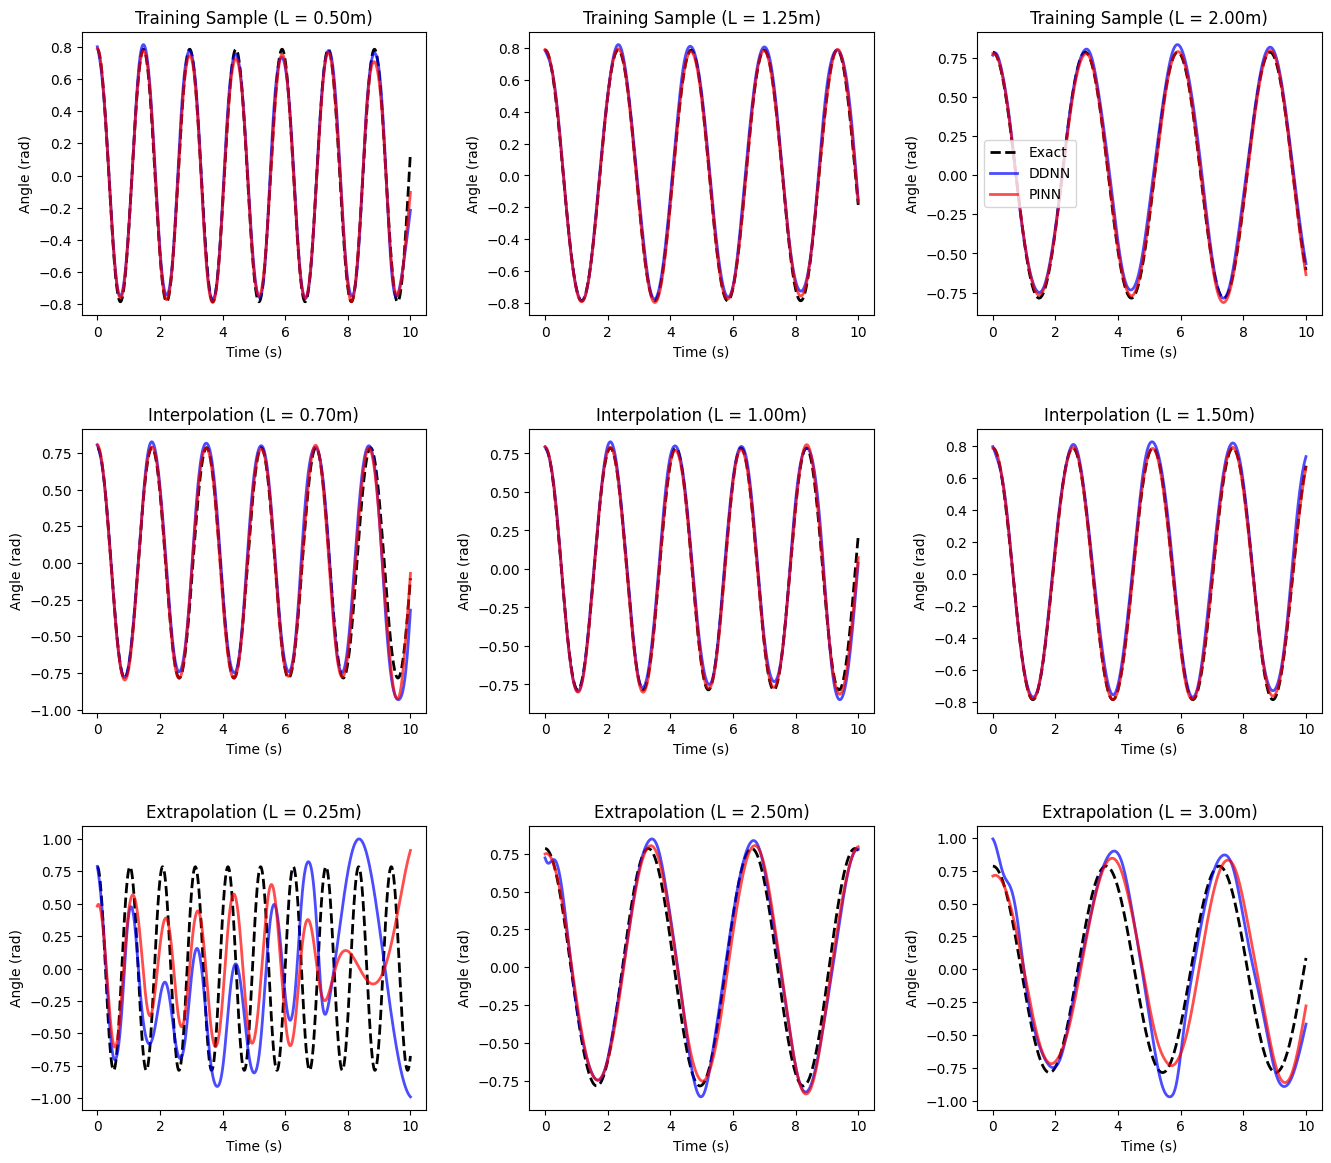

In [14]:
# --- TRAINING LOOP 10,000 Steps - Model (2, 64, 64, 64, 64, 1) ---
key = jax.random.PRNGKey(0)
layers = [2, 64, 64, 64, 64, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(10000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING (3 Rows: Training, Interpolation, Extrapolation) ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 3 training lengths)
print("--- TRAINING ERRORS (3 Samples) ---")
# Pick 3 representative lengths from your training set [0.5, 0.875, 1.25, 1.625, 2.0]
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end, resolution)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row)
print("\n--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

In [15]:
# Updated Scaling on Output Cosine
def NN(X, params):
    hidden, last = params[:-1], params[-1]
    for layer in hidden:
        # Swish for non-zero second derivatives
        X = jax.nn.swish(jnp.dot(X, layer['W']) + layer['B'])
        
    raw_out = jnp.dot(X, last['W']) + last['B']
    
    # Hard-constraining the physical amplitude!
    return (jnp.pi / 4.0) * jnp.cos(raw_out)

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 0.2287 | PINN L2: 0.2349
Train L=1.25 | DDNN L2: 0.2164 | PINN L2: 0.2166
Train L=2.00 | DDNN L2: 0.2245 | PINN L2: 0.2183

--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 0.2287 | PINN L2: 0.2124
L=1.00 | DDNN L2: 0.2125 | PINN L2: 0.2099
L=1.50 | DDNN L2: 0.2234 | PINN L2: 0.2181

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.1855 | PINN L2: 1.0449
L=2.50 | DDNN L2: 0.2402 | PINN L2: 0.2564
L=3.00 | DDNN L2: 0.3166 | PINN L2: 0.3996


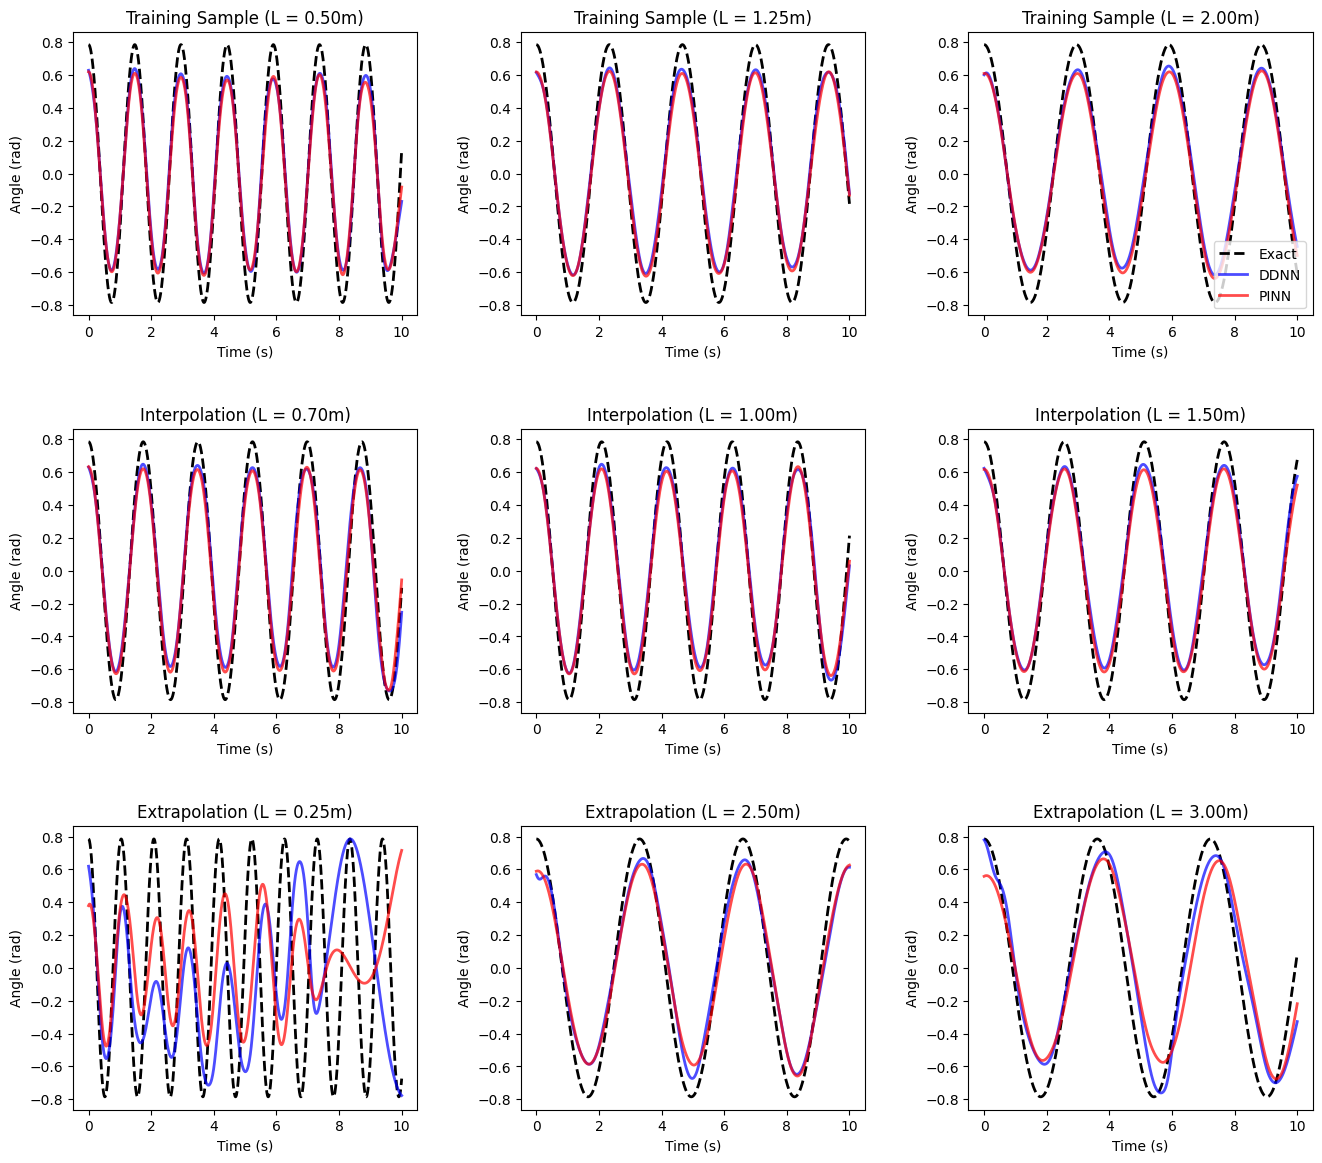

In [16]:
# --- TRAINING LOOP 10,000 Steps - Model (2, 64, 64, 64, 64, 1) ---
key = jax.random.PRNGKey(0)
layers = [2, 64, 64, 64, 64, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(10000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING (3 Rows: Training, Interpolation, Extrapolation) ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 3 training lengths)
print("--- TRAINING ERRORS (3 Samples) ---")
# Pick 3 representative lengths from your training set [0.5, 0.875, 1.25, 1.625, 2.0]
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end, resolution)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row)
print("\n--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

In [7]:
def NN(X, params):
    hidden, last = params[:-1], params[-1]
    for layer in hidden:
        # Swish prevents the long-term plateau!
        X = jax.nn.swish(jnp.dot(X, layer['W']) + layer['B'])
        
    # Standard linear output, no cosine or hard-coded amplitude
    return jnp.dot(X, last['W']) + last['B']

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 0.0686 | PINN L2: 0.0391
Train L=1.25 | DDNN L2: 0.0403 | PINN L2: 0.0162
Train L=2.00 | DDNN L2: 0.0303 | PINN L2: 0.0206

--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 0.2238 | PINN L2: 0.1008
L=1.00 | DDNN L2: 0.0462 | PINN L2: 0.0613
L=1.50 | DDNN L2: 0.0323 | PINN L2: 0.0181

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.5701 | PINN L2: 1.0634
L=2.50 | DDNN L2: 0.1369 | PINN L2: 0.1082
L=3.00 | DDNN L2: 0.2963 | PINN L2: 0.2295


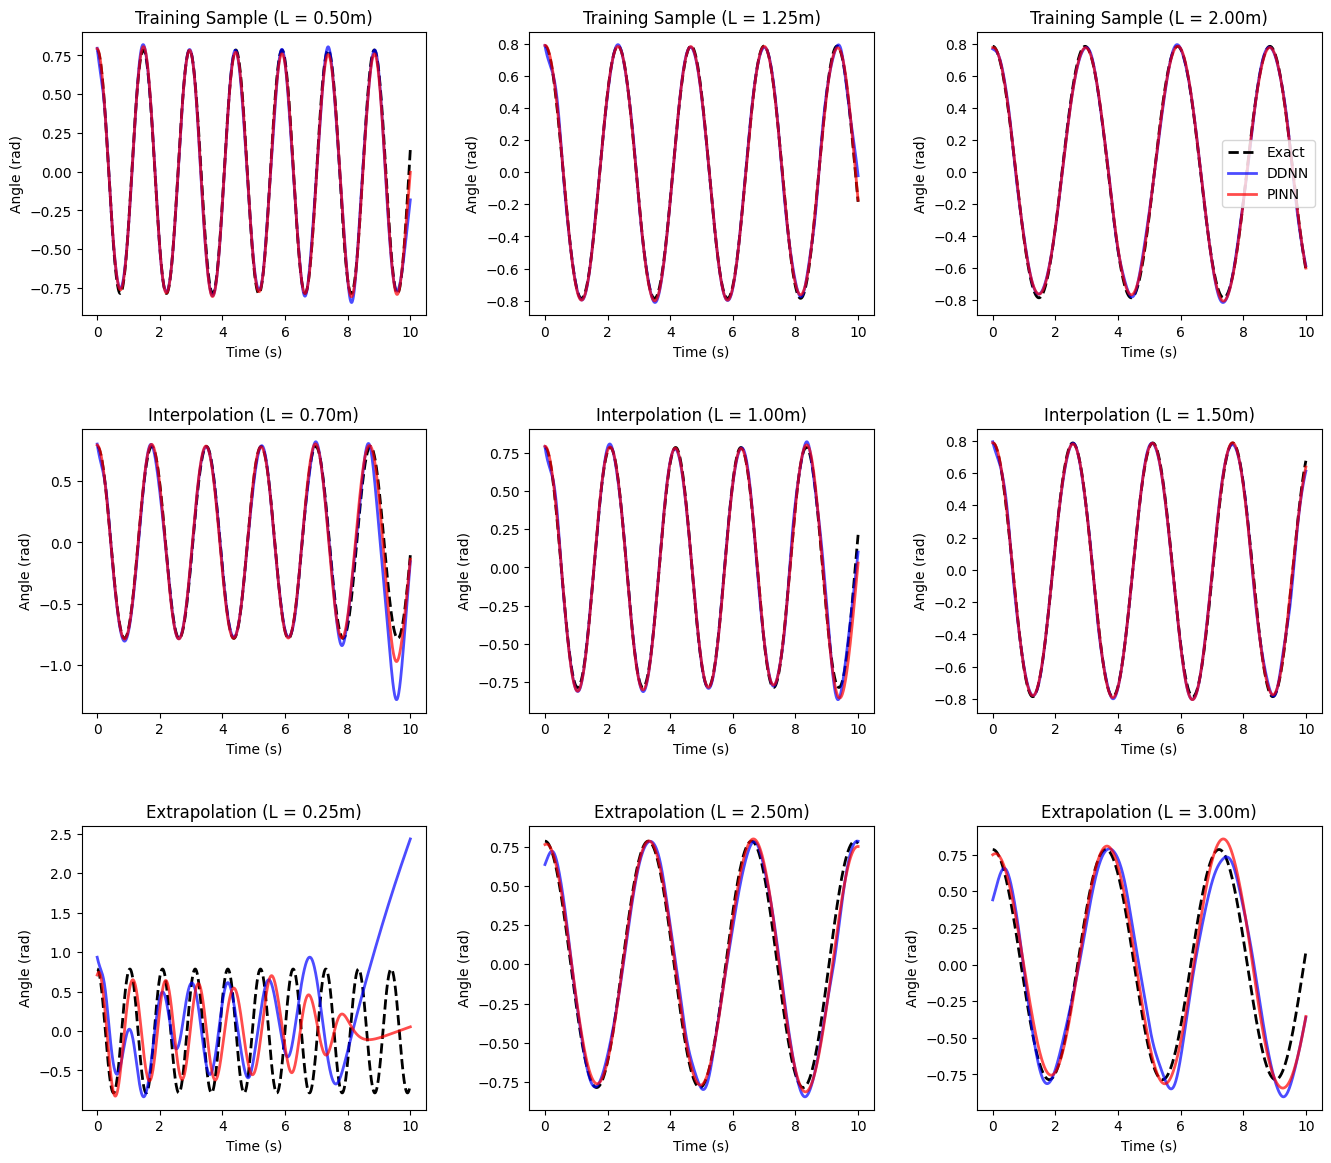

In [8]:
# --- TRAINING LOOP 10,000 Steps - Model (2, 64, 64, 64, 64, 1) ---
key = jax.random.PRNGKey(0)
layers = [2, 64, 64, 64, 64, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(10000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING (3 Rows: Training, Interpolation, Extrapolation) ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 3 training lengths)
print("--- TRAINING ERRORS (3 Samples) ---")
# Pick 3 representative lengths from your training set [0.5, 0.875, 1.25, 1.625, 2.0]
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end, resolution)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row)
print("\n--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

### Results and Findings: Swish Activation + Cosine Output - 10,000 Training Steps

Building upon our discovery regarding activation saturation, we replaced the `tanh` hidden layers with the Swish (SiLU) activation function and implemented a pure cosine output layer to naturally enforce periodicity. The initial model trained using this new architecture produced exceptional results. It matched the training and interpolation targets almost perfectly, only struggling slightly on extreme high-frequency extrapolations (low $L$). 

**The Hard-Constraint Experiment:**
Recognizing that the pendulum's initial state restricts its amplitude to exactly $[-\pi/4, \pi/4]$, we attempted to explicitly "hard-constrain" the architecture by multiplying the cosine output by this exact scalar ($\pi/4$). The goal was to remove amplitude guesswork entirely. However, this strategy actually degraded performance, causing the model to consistently undershoot the true target peaks. This undershooting occurred because the non-linear nature of a real 45-degree pendulum swing creates slightly flatter peaks than a perfect mathematical cosine wave; imposing a strict amplitude ceiling prevented the optimizer from making the minute adjustments necessary to fit the true physics.

**The Linear Output Ablation:**
To further isolate the impact of the Swish activations, we ran a final test removing the cosine function entirely, relying on Swish hidden layers with a standard linear output neuron. While this model successfully avoided the long-horizon plateauing seen in earlier `tanh` networks, its overall predictive accuracy fell slightly short of the precision achieved by the unscaled cosine output architecture. Ultimately, the combination of Swish (for gradient stability and saturation prevention) and an unscaled Cosine final layer (for implicit periodic bounds) proved to be the most robust solution.

In [9]:
# ==========================================
# 1. ARCHITECTURE & PHYSICS RESIDUAL 
# (Time-Warping + Swish + Pure Cosine)
# ==========================================
def init_params(key, layers_omega, layers_wave):
    key_w, key_t = jax.random.split(key)
    
    def init_mlp(k, layers):
        keys = jax.random.split(k, len(layers) - 1)
        params = []
        for k_i, n_in, n_out in zip(keys, layers[:-1], layers[1:]):
            W = jax.random.uniform(k_i, shape=(n_in, n_out), minval=-np.sqrt(1/n_in), maxval=np.sqrt(1/n_in))
            B = jnp.zeros((n_out,))
            params.append({'W': W, 'B': B})
        return params
        
    # Return a dictionary containing both sub-networks
    return {
        'omega': init_mlp(key_w, layers_omega),
        'wave': init_mlp(key_t, layers_wave)
    }

def evaluate_mlp(X, params):
    hidden, last = params[:-1], params[-1]
    for layer in hidden:
        # Replaced tanh with Swish to prevent saturation plateaus
        X = jax.nn.swish(jnp.dot(X, layer['W']) + layer['B'])
    # Return the linear raw output 
    return jnp.dot(X, last['W']) + last['B']

def NN(X, params):
    t = X[..., 0:1] # Extract time
    L = X[..., 1:2] # Extract length
    
    # 1. Branch A: Predict frequency scaling (omega) from Length
    w = evaluate_mlp(L, params['omega'])
    
    # 2. Merge: Warp Time
    tau = w * t
    
    # 3. Branch B: Predict raw final angle from warped time
    raw_theta = evaluate_mlp(tau, params['wave'])
    
    # 4. Pure Cosine constraint on the final output ONLY
    return jnp.cos(raw_theta)

# Scalar version for clean differentiation
def get_theta_scalar(params, t, L):
    X = jnp.array([t, L])
    return NN(X, params)[0]

# Differentiate ONLY with respect to time (argnums=1)
grad_t = jax.grad(get_theta_scalar, argnums=1)
grad_tt = jax.grad(grad_t, argnums=1)

def r_PINN_scalar(params, t, L):
    theta = get_theta_scalar(params, t, L)
    theta_tt = grad_tt(params, t, L)
    return theta_tt + (9.81 / L) * jnp.sin(theta)

r_PINN_vmap = jax.vmap(r_PINN_scalar, in_axes=(None, 0, 0))

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 0.6370 | PINN L2: 0.5270
Train L=1.25 | DDNN L2: 0.1937 | PINN L2: 0.0694
Train L=2.00 | DDNN L2: 0.1079 | PINN L2: 0.0567

--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 0.5371 | PINN L2: 0.3841
L=1.00 | DDNN L2: 0.3941 | PINN L2: 0.0880
L=1.50 | DDNN L2: 0.1138 | PINN L2: 0.0609

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.1698 | PINN L2: 0.7326
L=2.50 | DDNN L2: 0.1045 | PINN L2: 0.1845
L=3.00 | DDNN L2: 0.0887 | PINN L2: 0.7265


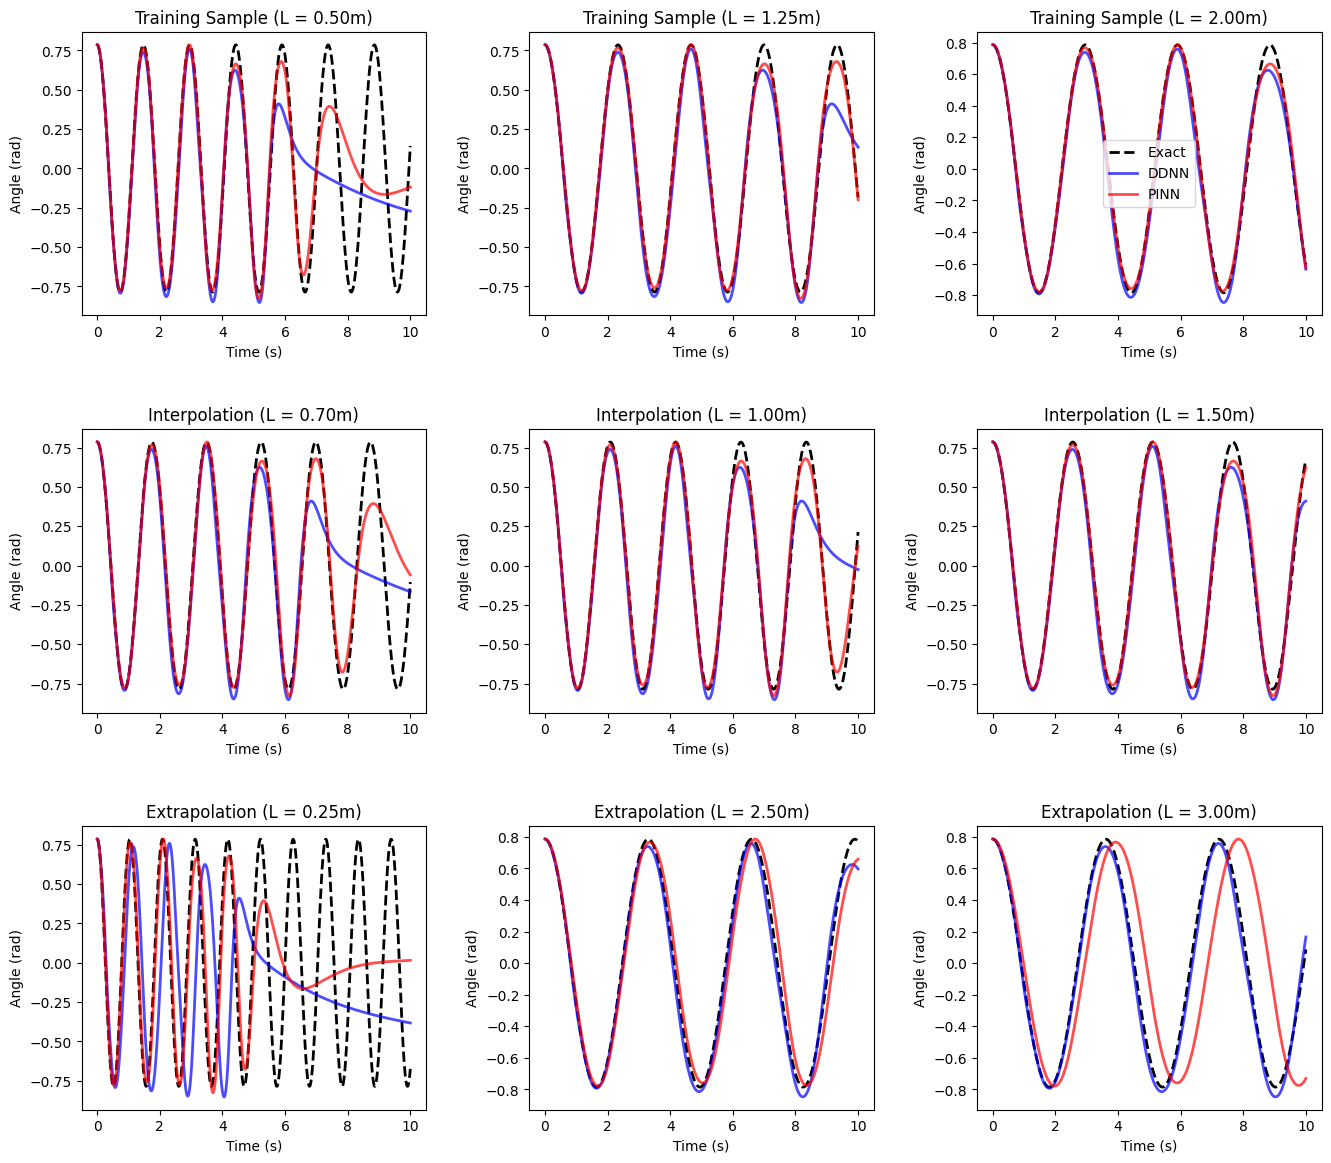

In [10]:
# ==========================================
# 2. TRAINING LOOP (10,000 Steps)
# ==========================================
key = jax.random.PRNGKey(0)

# Branch A: Takes 1 input (L), uses 2 small hidden layers, outputs 1 (omega)
layers_omega = [1, 10, 10, 1] 

# Branch B: Takes 1 input (tau), uses 3 hidden layers, outputs 1 (raw_theta)
layers_wave = [1, 20, 20, 20, 1] 

params_DDNN = init_params(key, layers_omega, layers_wave)
params_PINN = init_params(key, layers_omega, layers_wave)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(10000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")


# ==========================================
# 3. ANALYTICS & PLOTTING (3x3 Grid)
# ==========================================
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 3 training lengths)
print("--- TRAINING ERRORS (3 Samples) ---")
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end, resolution)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row)
print("\n--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 0.4854 | PINN L2: 0.2502
Train L=1.25 | DDNN L2: 0.1615 | PINN L2: 0.0636
Train L=2.00 | DDNN L2: 0.1820 | PINN L2: 0.0725

--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 0.3544 | PINN L2: 0.1888
L=1.00 | DDNN L2: 0.1403 | PINN L2: 0.0554
L=1.50 | DDNN L2: 0.1705 | PINN L2: 0.0815

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.5197 | PINN L2: 1.3351
L=2.50 | DDNN L2: 0.3055 | PINN L2: 0.2727
L=3.00 | DDNN L2: 0.6502 | PINN L2: 0.8025


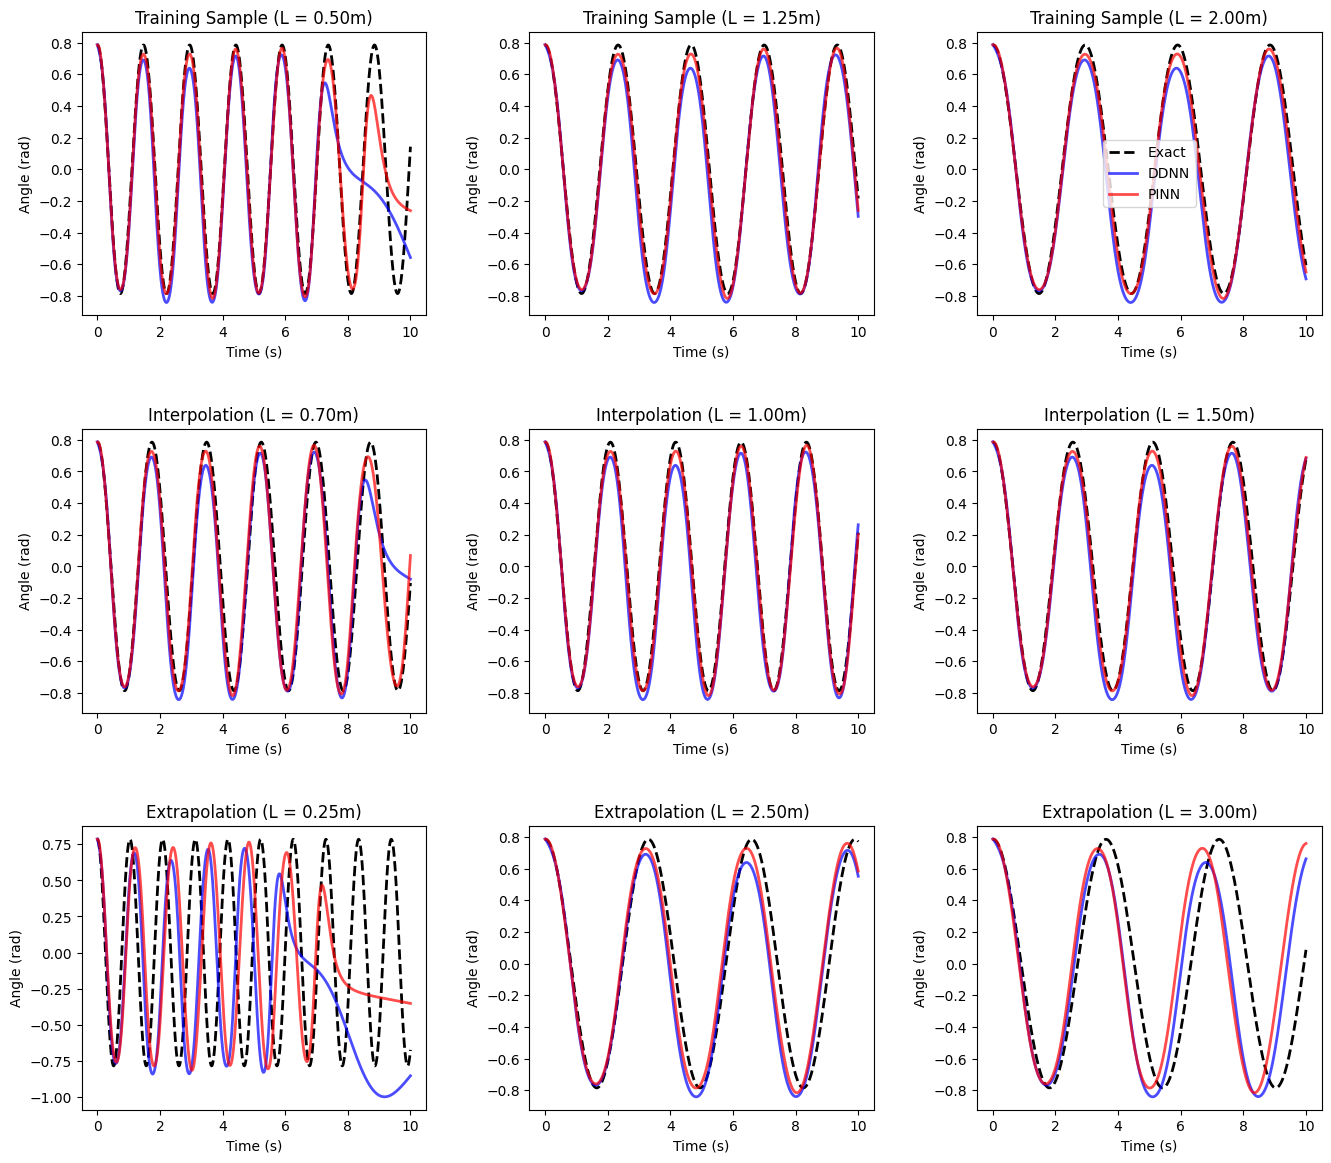

In [11]:
# ==========================================
# 2. TRAINING LOOP (10,000 Steps)
# ==========================================
key = jax.random.PRNGKey(0)

# Branch A: Takes 1 input (L), uses 2 small hidden layers, outputs 1 (omega)
layers_omega = [1, 20, 20, 1] 

# Branch B: Takes 1 input (tau), uses 3 hidden layers, outputs 1 (raw_theta)
layers_wave = [1, 64, 64, 64, 1] 

params_DDNN = init_params(key, layers_omega, layers_wave)
params_PINN = init_params(key, layers_omega, layers_wave)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(10000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")


# ==========================================
# 3. ANALYTICS & PLOTTING (3x3 Grid)
# ==========================================
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 3 training lengths)
print("--- TRAINING ERRORS (3 Samples) ---")
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end, resolution)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row)
print("\n--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

### Results and Findings: Time-Warping Architecture with Swish and Cosine Output - 10,000 Training Steps

Motivated by our previous time-warping model's success at isolating and capturing frequency dynamics, we hypothesized that upgrading its internal structure with Swish activations and a pure Cosine output layer would yield our best results yet. 

However, empirical testing proved otherwise. The performance of this decoupled, structurally constrained model fell significantly below that of the standard, unified network architecture. To ensure this wasn't merely a capacity bottleneck, we ran an additional ablation expanding the network width of the sub-models significantly. Despite the increased parameter count, performance still fell short of the standard unstructured PINN.

This outcome is a prime example of "The Bitter Lesson" in machine learning research. It strongly suggests that allowing a sufficiently wide model equipped with robust mathematical properties (like Swish and Cosine bounds) to learn frequencies *implicitly* is far more effective than attempting to *explicitly* force human-engineered structural biases (like the branching time-warp) into the network.

In [ ]:
# --- Data Generation ---
g_const = 9.81
initial_state = [np.pi/4, 0.0]

def rhs(state, t, L, g):
    theta, theta_dot = state
    return [theta_dot, -(g / L) * np.sin(theta)]

def generate_trajectory(L, t_end, num_points):
    t_arr = np.linspace(0, t_end, num_points)
    states = odeint(rhs, initial_state, t_arr, args=(L, g_const))
    return t_arr.reshape(-1, 1), np.full_like(t_arr, L).reshape(-1, 1), states[:, 0:1]

# Time horizon to ensure multiple cycles
t_end = 50.0
resolution = 1000 # High resolution for the exact curves

# 1. Training Data (L bounds: [0.5, 2.0])
np.random.seed(42)
L_train_vals = [0.5, 0.875, 1.25, 1.625, 2.0]
X_train_list, theta_train_list = [], []

for L in L_train_vals:
    t_arr, L_arr, theta_arr = generate_trajectory(L, t_end, resolution)
    # Sample 40 sparse points across the 10 seconds for each length
    t_samp, L_samp, theta_samp = t_arr[0::5], L_arr[0::5], theta_arr[0::5]
    theta_samp += np.random.normal(0, 0.02, size=theta_samp.shape) # Add noise
    
    X_train_list.append(np.hstack([t_samp, L_samp]))
    theta_train_list.append(theta_samp)

X_train = np.vstack(X_train_list)
theta_train = jnp.array(np.vstack(theta_train_list))

# 2. Multiple Interpolations (Lengths inside [0.5, 2.0])
L_interp_vals = [0.7, 1.0, 1.5]
interp_data = [generate_trajectory(L, t_end, resolution) for L in L_interp_vals]

# 3. Multiple Extrapolations (Lengths outside [0.5, 2.0])
L_extrap_vals = [0.25, 2.5, 3.0]
extrap_data = [generate_trajectory(L, t_end, resolution) for L in L_extrap_vals]

# 4. Expanded Collocation Points Cloud
# We increase to 2000 points because the t and L domains are much larger now
lhs = LatinHypercube(d=2, seed=0)
samples = lhs.random(n=2000)
t_col = (0.0 + (t_end - 0.0) * samples[:, 0]).flatten()
L_col = (0.25 + (3.0 - 0.25) * samples[:, 1]).flatten()

In [16]:
# --- ARCHITECTURE & PHYSICS RESIDUAL ---
def init_params(key, layers):
    keys = jax.random.split(key, len(layers) - 1)
    params = []
    for k, n_in, n_out in zip(keys, layers[:-1], layers[1:]):
        W = jax.random.uniform(k, shape=(n_in, n_out), minval=-np.sqrt(1/n_in), maxval=np.sqrt(1/n_in))
        B = jnp.zeros((n_out,))
        params.append({'W': W, 'B': B})
    return params

def NN(X, params):
    hidden, last = params[:-1], params[-1]
    for layer in hidden:
        # 1. Replaced tanh with Swish to avoid saturation but keep 2nd derivatives
        X = jax.nn.swish(jnp.dot(X, layer['W']) + layer['B'])
        
    # 2. Calculate the raw output of the final layer
    raw_out = jnp.dot(X, last['W']) + last['B']
    
    # 3. Apply your idea: A one-neuron cosine final function
    return jnp.cos(raw_out)

# Scalar version of the network for clean differentiation
def get_theta_scalar(params, t, L):
    X = jnp.array([t, L])
    return NN(X, params)[0]

# Differentiate ONLY with respect to time (argnums=1)
grad_t = jax.grad(get_theta_scalar, argnums=1)
grad_tt = jax.grad(grad_t, argnums=1)

def r_PINN_scalar(params, t, L):
    theta = get_theta_scalar(params, t, L)
    theta_tt = grad_tt(params, t, L)
    return theta_tt + (9.81 / L) * jnp.sin(theta)

# Vectorize the scalar residual function for batch processing
r_PINN_vmap = jax.vmap(r_PINN_scalar, in_axes=(None, 0, 0))

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 1.4213 | PINN L2: 1.2719
Train L=1.25 | DDNN L2: 0.9569 | PINN L2: 0.8898
Train L=2.00 | DDNN L2: 0.7752 | PINN L2: 0.8194

--- INTERPOLATION ERRORS ---
L=0.70 | DDNN L2: 1.2952 | PINN L2: 1.0476
L=1.00 | DDNN L2: 1.2384 | PINN L2: 1.0579
L=1.50 | DDNN L2: 1.2665 | PINN L2: 1.1219

--- EXTRAPOLATION ERRORS ---
L=0.25 | DDNN L2: 1.4181 | PINN L2: 1.0319
L=2.50 | DDNN L2: 1.3151 | PINN L2: 0.9189
L=3.00 | DDNN L2: 1.3095 | PINN L2: 0.9542


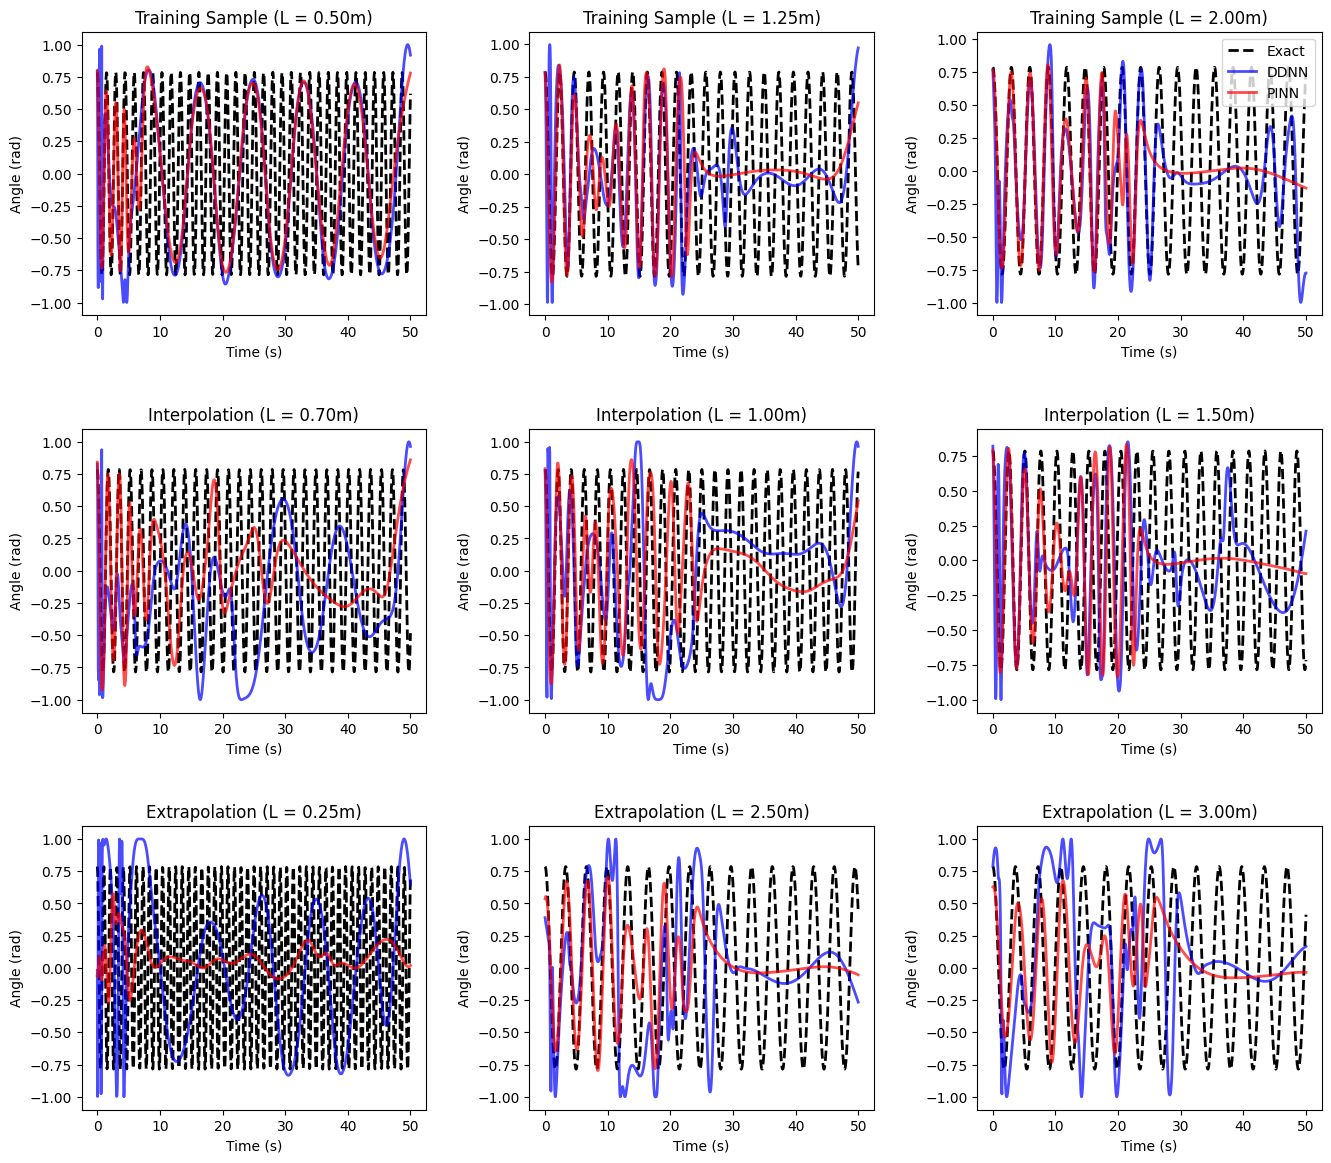

In [17]:
# --- TRAINING LOOP 10,000 Steps - Model (2, 64, 64, 64, 64, 1) ---
key = jax.random.PRNGKey(0)
layers = [2, 128, 128, 128, 128, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(10000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING (3 Rows: Training, Interpolation, Extrapolation) ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 3 training lengths)
print("--- TRAINING ERRORS (3 Samples) ---")
# Pick 3 representative lengths from your training set [0.5, 0.875, 1.25, 1.625, 2.0]
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end, resolution)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row)
print("\n--- INTERPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row)
print("\n--- EXTRAPOLATION ERRORS ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

In [20]:
# --- Data Generation ---
g_const = 9.81
initial_state = [np.pi/4, 0.0]

def rhs(state, t, L, g):
    theta, theta_dot = state
    return [theta_dot, -(g / L) * np.sin(theta)]

def generate_trajectory(L, t_end, num_points):
    t_arr = np.linspace(0, t_end, num_points)
    states = odeint(rhs, initial_state, t_arr, args=(L, g_const))
    return t_arr.reshape(-1, 1), np.full_like(t_arr, L).reshape(-1, 1), states[:, 0:1]

# Separate time horizons for training and testing
t_end_train = 10.0  # Keep training constrained to the first 10 seconds
t_end_test = 50.0   # Test the model's ability to extrapolate out to 50 seconds

# Resolution
resolution_train = 1000
resolution_test = 5000 # Increased so the 50s plots stay perfectly smooth

# 1. Training Data (L bounds: [0.5, 2.0])
np.random.seed(42)
L_train_vals = [0.5, 0.875, 1.25, 1.625, 2.0]
X_train_list, theta_train_list = [], []

for L in L_train_vals:
    t_arr, L_arr, theta_arr = generate_trajectory(L, t_end_train, resolution_train)
    
    # [0::12] grabs roughly 83 data points (double your previous 40 points)
    t_samp, L_samp, theta_samp = t_arr[0::12], L_arr[0::12], theta_arr[0::12]
    theta_samp += np.random.normal(0, 0.02, size=theta_samp.shape) # Add noise
    
    X_train_list.append(np.hstack([t_samp, L_samp]))
    theta_train_list.append(theta_samp)

X_train = np.vstack(X_train_list)
theta_train = jnp.array(np.vstack(theta_train_list))

# 2. Multiple Interpolations (Lengths inside [0.5, 2.0])
L_interp_vals = [0.7, 1.0, 1.5]
# Use t_end_test (50s) here
interp_data = [generate_trajectory(L, t_end_test, resolution_test) for L in L_interp_vals]

# 3. Multiple Extrapolations (Lengths outside [0.5, 2.0])
L_extrap_vals = [0.25, 2.5, 3.0]
# Use t_end_test (50s) here
extrap_data = [generate_trajectory(L, t_end_test, resolution_test) for L in L_extrap_vals]

# 4. Expanded Collocation Points Cloud
# CRITICAL: We enforce physics over the full 50s (t_end_test) using 10,000 points.
# This forces the network to maintain its frequency even where it has no training data!
lhs = LatinHypercube(d=2, seed=0)
samples = lhs.random(n=10000)
t_col = (0.0 + (t_end_test - 0.0) * samples[:, 0]).flatten()
L_col = (0.25 + (3.0 - 0.25) * samples[:, 1]).flatten()

Training started...
Training complete.
--- TRAINING ERRORS (3 Samples) ---
Train L=0.50 | DDNN L2: 0.0533 | PINN L2: 0.0351
Train L=1.25 | DDNN L2: 0.0183 | PINN L2: 0.0173
Train L=2.00 | DDNN L2: 0.0183 | PINN L2: 0.0186

--- INTERPOLATION ERRORS (50s Horizon) ---
L=0.70 | DDNN L2: 1.3918 | PINN L2: 0.8750
L=1.00 | DDNN L2: 1.4429 | PINN L2: 0.8533
L=1.50 | DDNN L2: 1.3159 | PINN L2: 0.8942

--- EXTRAPOLATION ERRORS (50s Horizon) ---
L=0.25 | DDNN L2: 1.6451 | PINN L2: 1.0157
L=2.50 | DDNN L2: 1.3525 | PINN L2: 0.7853
L=3.00 | DDNN L2: 1.3896 | PINN L2: 0.9346


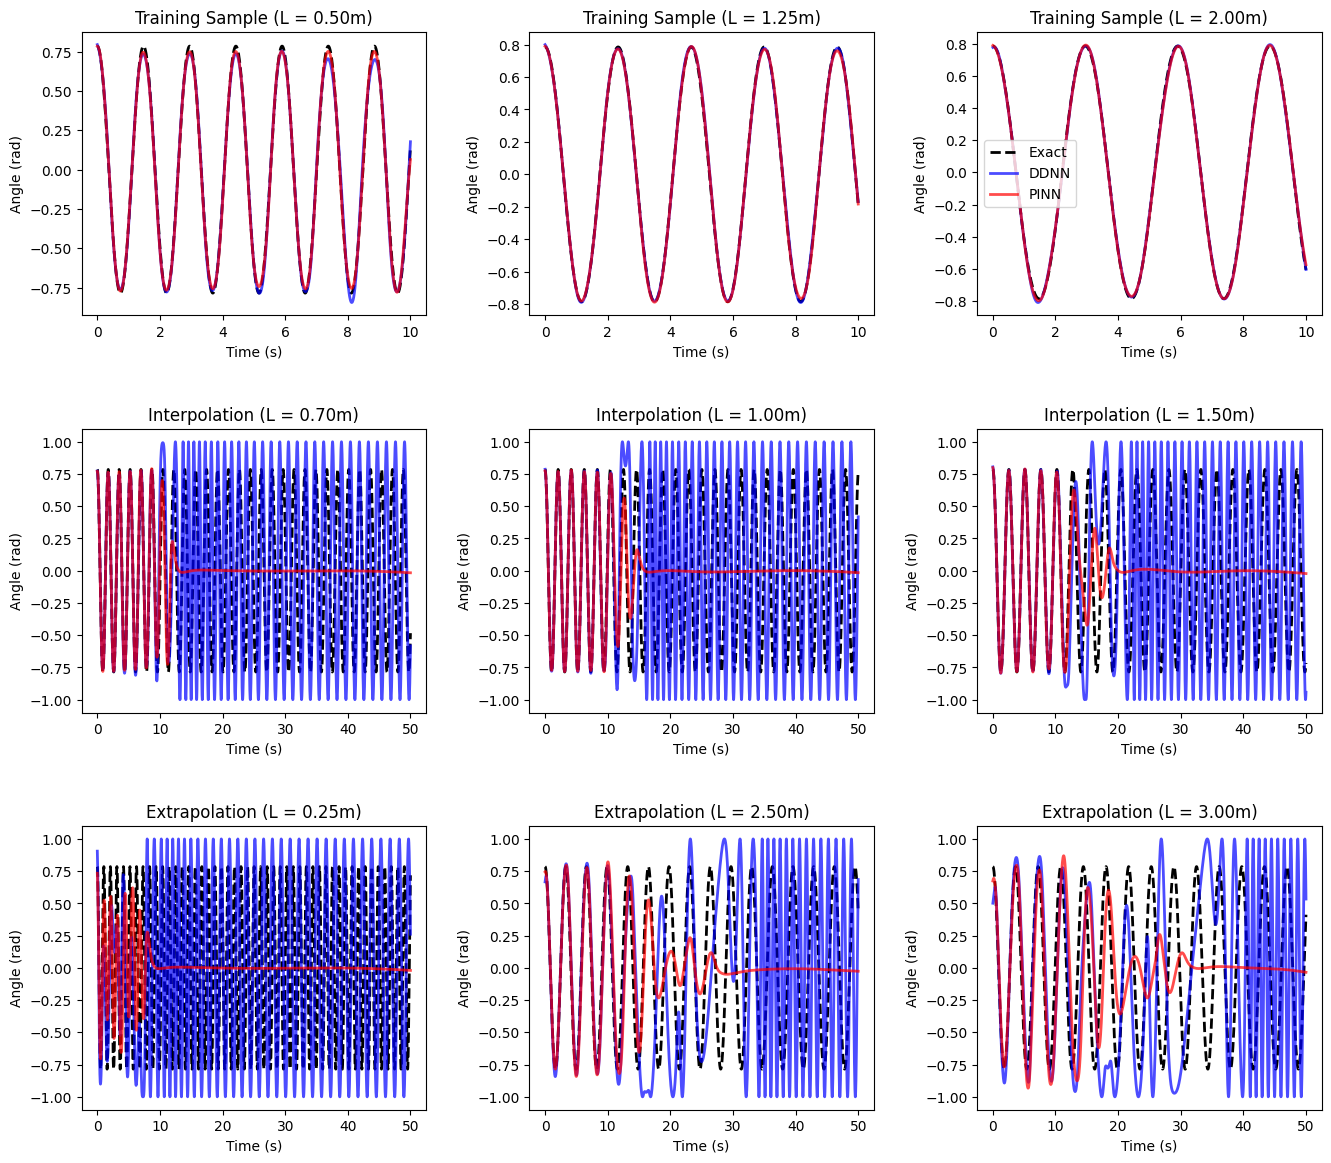

In [21]:
# --- TRAINING LOOP 10,000 Steps - Model (2, 64, 64, 64, 64, 1) ---
key = jax.random.PRNGKey(0)
layers = [2, 64, 64, 64, 64, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(10000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- ANALYTICS & PLOTTING (3 Rows: Training, Interpolation, Extrapolation) ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Plot Training Data Samples (Top Row - 10s Window)
print("--- TRAINING ERRORS (3 Samples) ---")
train_sample_vals = [0.5, 1.25, 2.0] 
for i, L_val in enumerate(train_sample_vals):
    # FIXED: Using t_end_train and resolution_train for the top row
    t_arr, L_arr, theta_true = generate_trajectory(L_val, t_end_train, resolution_train)
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"Train L={L_val:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[0, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Training Sample (L = {L_val:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")
    if i == 2:
        ax.legend()

# 2. Plot Multiple Interpolations (Middle Row - 50s Window)
print("\n--- INTERPOLATION ERRORS (50s Horizon) ---")
for i, (t_arr, L_arr, theta_true) in enumerate(interp_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_interp_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[1, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Interpolation (L = {L_interp_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

# 3. Plot Multiple Extrapolations (Bottom Row - 50s Window)
print("\n--- EXTRAPOLATION ERRORS (50s Horizon) ---")
for i, (t_arr, L_arr, theta_true) in enumerate(extrap_data):
    X_test = jnp.array(np.hstack([t_arr, L_arr]))
    pred_DDNN = NN(X_test, params_DDNN)
    pred_PINN = NN(X_test, params_PINN)
    
    print(f"L={L_extrap_vals[i]:.2f} | DDNN L2: {compute_l2(theta_true, pred_DDNN):.4f} | PINN L2: {compute_l2(theta_true, pred_PINN):.4f}")
    
    ax = axes[2, i]
    ax.plot(t_arr, theta_true, 'k--', linewidth=2, label="Exact")
    ax.plot(t_arr, pred_DDNN, 'b-', alpha=0.7, linewidth=2, label="DDNN")
    ax.plot(t_arr, pred_PINN, 'r-', alpha=0.7, linewidth=2, label="PINN")
    ax.set_title(f"Extrapolation (L = {L_extrap_vals[i]:.2f}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (rad)")

plt.show()

### Results and Findings: Scaling to a 50-Second Time Horizon - 10,000 Training Steps

Given the success of the Swish and unscaled Cosine architecture on the 10-second domain, we expanded our testing to a massive 50-second time horizon.

**The Data Sparsity Problem:**
In our initial 50-second test, we kept the absolute number of training points the same but stretched them across the entire 50-second window. This led to severe performance degradation. The data became too sparse—dropping below the threshold of one point per pendulum swing—leaving the model completely unable to anchor onto a consistent frequency pattern.

**The Temporal Extrapolation Test:**
To resolve the sparsity issue, we designed a rigorous temporal extrapolation test. We confined a high-density set of training data strictly to the first 10 seconds, but evaluated the model's predictions out to 50 seconds (enforcing physics collocation points across the entire domain).

Interestingly, the model performed exceptionally well within the 10-second training window, successfully interpolating and extrapolating across varying rod lengths ($L$), with the exception of extreme high-frequency cases. However, immediately beyond the 10-second boundary, the PINN's predictions rapidly collapsed back to the mean.

This reveals a critical limitation in the network's learning mechanics: while the model successfully mapped the complex relationship between $L$ and frequency within its localized training domain, it did not learn a globally generalized periodic function. Despite the physical constraints and the Cosine output layer, the model struggles to propagate the wave through time without continuous data anchors.